# **CycleGAN Project: Sandals ↔ Sneakers Translation**

## **Introduction**

In this project, we apply CycleGAN to translate between two categories of the **Fashion-MNIST** dataset:  

- **Domain A:** Sandals  
- **Domain B:** Sneakers  

The goal is to generate realistic images of sneakers from sandals and vice versa, demonstrating CycleGAN's capability to learn style and structure transformations between unpaired datasets.


In [ ]:
# Basic PyTorch ecosystem (if not preinstalled)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# Pillow for image handling
!pip install pillow

# numpy & matplotlib for visualization
!pip install numpy matplotlib

# Optional: FID computation / evaluation metrics
!pip install scipy scikit-image

# Git clone CycleGAN repo
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git
!cd pytorch-CycleGAN-and-pix2pix

# Other dependencies
!pip install -r requirements.txt


## **2. Dataset & Preprocessing**

### **Dataset**
We use the **Fashion-MNIST** dataset, which has 10 classes of fashion objects with 28x28 grayscale images. We primarily use two classes:

- **Domain A:** Sandals (label `5`)  
- **Domain B:** Sneakers (label `7`) 

These two classes serve as the source and the target domain. 

### **Preprocessing**

Preprocessing mainly involved resizing the images to 128x128 pixels to match the input requirements of the CycleGAN. Since they were grayscale images, they were converted to RGB (3 channels) to be compatible with the standard CycleGAN architecture. 
The preprocessed images were then saved in seperate folders. Further, in case one of the domain had more images, it was truncated to match the smaller dataset to ensure stable training and to prevent bias towards one domain.


In [5]:
import os
import random
from torchvision import datasets, transforms
from PIL import Image

# --------------------------
# Parameters
# --------------------------
output_dir = "/workspace/datasets/fashion"
os.makedirs(os.path.join(output_dir, "trainA"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "trainB"), exist_ok=True)

domainA_label = 5  # sandals
domainB_label = 7  # sneakers
img_size = 128

# --------------------------
# Download Fashion-MNIST
# --------------------------
train_dataset = datasets.FashionMNIST(root='/workspace/fashion_mnist', train=True, download=True)

# --------------------------
# Preprocessing & Save
# --------------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size))
])

countA, countB = 0, 0

for idx, (img, label) in enumerate(train_dataset):
    if label == domainA_label:
        img = transform(img).convert("RGB")
        img.save(os.path.join(output_dir, "trainA", f"{countA}.png"))
        countA += 1
    elif label == domainB_label:
        img = transform(img).convert("RGB")
        img.save(os.path.join(output_dir, "trainB", f"{countB}.png"))
        countB += 1

# --------------------------
# Balance datasets
# --------------------------
trainA_files = os.listdir(os.path.join(output_dir, "trainA"))
trainB_files = os.listdir(os.path.join(output_dir, "trainB"))
min_len = min(len(trainA_files), len(trainB_files))

# Truncate larger set
if len(trainA_files) > min_len:
    for f in trainA_files[min_len:]:
        os.remove(os.path.join(output_dir, "trainA", f))
if len(trainB_files) > min_len:
    for f in trainB_files[min_len:]:
        os.remove(os.path.join(output_dir, "trainB", f))

print(f"Preprocessing done! Domain A: {min_len} images, Domain B: {min_len} images")


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.66MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 11.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.34MB/s]


Preprocessing done! Domain A: 6000 images, Domain B: 6000 images


TrainA samples:


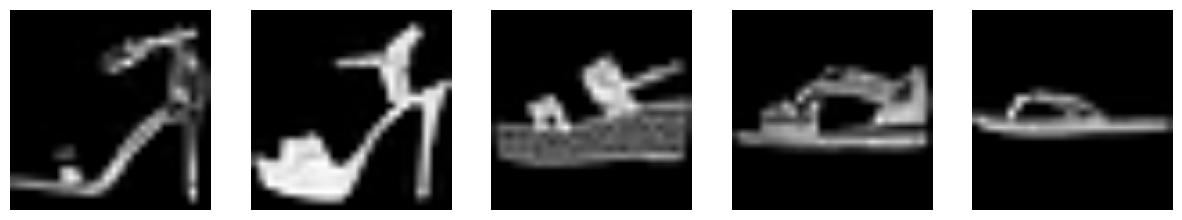

TrainB samples:


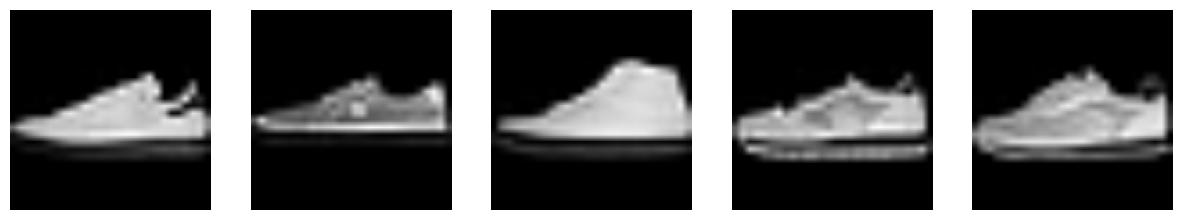

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

# Helper function
def show_images(path, n=5):
    files = os.listdir(path)[:n]  # take first n images
    plt.figure(figsize=(15,3))
    for i, file in enumerate(files):
        img = Image.open(os.path.join(path, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

# visualize TrainA and TrainB
print("TrainA samples:")
show_images(trainA_path, n=5)

print("TrainB samples:")
show_images(trainB_path, n=5)


### **Training Command**

The training command used is as mentioned below. The main parameters include:

- `--batch_size 4`: Number of images per batch. Smaller batches are often used to stabilize training.
- `--load_size 128` & `--crop_size 128`: Images are first resized to `load_size` and center cropped to `crop_size`. Since our dataset images are already 128×128, cropping does not alter the size. This is just included for compatibility with the training script.
- `--n_epochs 25`: Number of epochs with a fixed learning rate.
- `--n_epochs_decay 0`: Number of epochs to linearly decay the learning rate. Set to 0 here, so the learning rate remains constant throughout training.


In [ ]:
!/venv/main/bin/python /workspace/pytorch-CycleGAN-and-pix2pix/train.py \
  --dataroot /workspace/datasets/fashion \
  --name fashion_cyclegan \
  --model cycle_gan \
  --batch_size 4 \
  --load_size 128 \
  --crop_size 128 \
  --n_epochs 25 \
  --n_epochs_decay 0 \
  --checkpoints_dir /workspace/checkpoints \
  --save_epoch_freq 1


Loading the trained model:

model [CycleGANModel] was created
Initialized with device cuda:0
initialize network with normal
loading the model from /workspace/checkpoints/fashion_cyclegan/latest_net_G_A.pth
Initialized with device cuda:0
initialize network with normal
loading the model from /workspace/checkpoints/fashion_cyclegan/latest_net_G_B.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 11.378 M
[Network G_B] Total number of parameters : 11.378 M
-----------------------------------------------
CycleGAN model loaded successfully.


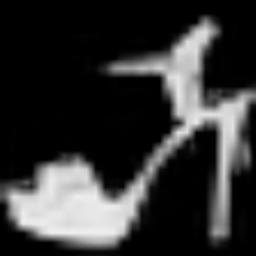

In [ ]:
import torch
from models import create_model
from PIL import Image
from torchvision import transforms

import os
os.chdir('/workspace/pytorch-CycleGAN-and-pix2pix')
import sys
sys.path.append('.') 

# Paths
repo_path = '/workspace/pytorch-CycleGAN-and-pix2pix'
ckpt_dir = '/workspace/checkpoints/fashion_cyclegan'
ckpt_name = 'latest_net_G_A.pth'  # adjust if different
img_path = '/workspace/datasets/fashion/trainA/1.png'

# Minimal options for loading model

class MinimalOptions:
    def __init__(self):
        # BaseModel requirements
        self.isTrain = False
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.name = 'fashion_cyclegan'
        self.checkpoints_dir = '/workspace/checkpoints'
        self.load_iter = 0        # needed by BaseModel.setup
        self.epoch = 'latest'     # load latest checkpoint
        
        # CycleGAN options
        self.model = 'cycle_gan'
        self.netG = 'resnet_9blocks'
        self.netD = 'basic'
        self.input_nc = 3
        self.output_nc = 3
        self.ngf = 64
        self.ndf = 64
        self.n_layers_D = 3
        self.norm = 'instance'
        self.no_dropout = True
        self.init_type = 'normal'
        self.init_gain = 0.02
        
        # Test options
        self.batch_size = 1
        self.serial_batches = True
        self.no_flip = True
        self.phase = 'test'
        self.num_test = float('inf')
        self.aspect_ratio = 1.0
        self.load_size = 256
        self.crop_size = 256
        self.preprocess = 'resize_and_crop'
        self.verbose = False
        self.suffix = ''

opt = MinimalOptions()

# Create model
model = create_model(opt)
model.setup(opt)
model.netG_A.eval()
model.netG_B.eval()
print("CycleGAN model loaded successfully.")

# Load and preprocess image
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
input_tensor = transform(img).unsqueeze(0).to(opt.device)

# Run inference
with torch.no_grad():
    fake_B = model.netG_A(input_tensor)
    fake_B = (fake_B + 1) / 2  # denormalize

# Convert to image and show
fake_B_img = transforms.ToPILImage()(fake_B.squeeze().cpu())
fake_B_img.show()


In [37]:
G_A=model.netG_A.eval()
G_B=model.netG_B.eval()

## **Training Loss Visualization**

During CycleGAN training, several losses are monitored to ensure stable and effective learning. These include:

- **Generator losses:** `G_A`, `G_B`  
- **Discriminator losses:** `D_A`, `D_B`  
- **Cycle-consistency losses:** `cycle_A`, `cycle_B`  
- **Identity losses:** `idt_A`, `idt_B`  

The plot below shows the average value of each loss per epoch over the training period.  


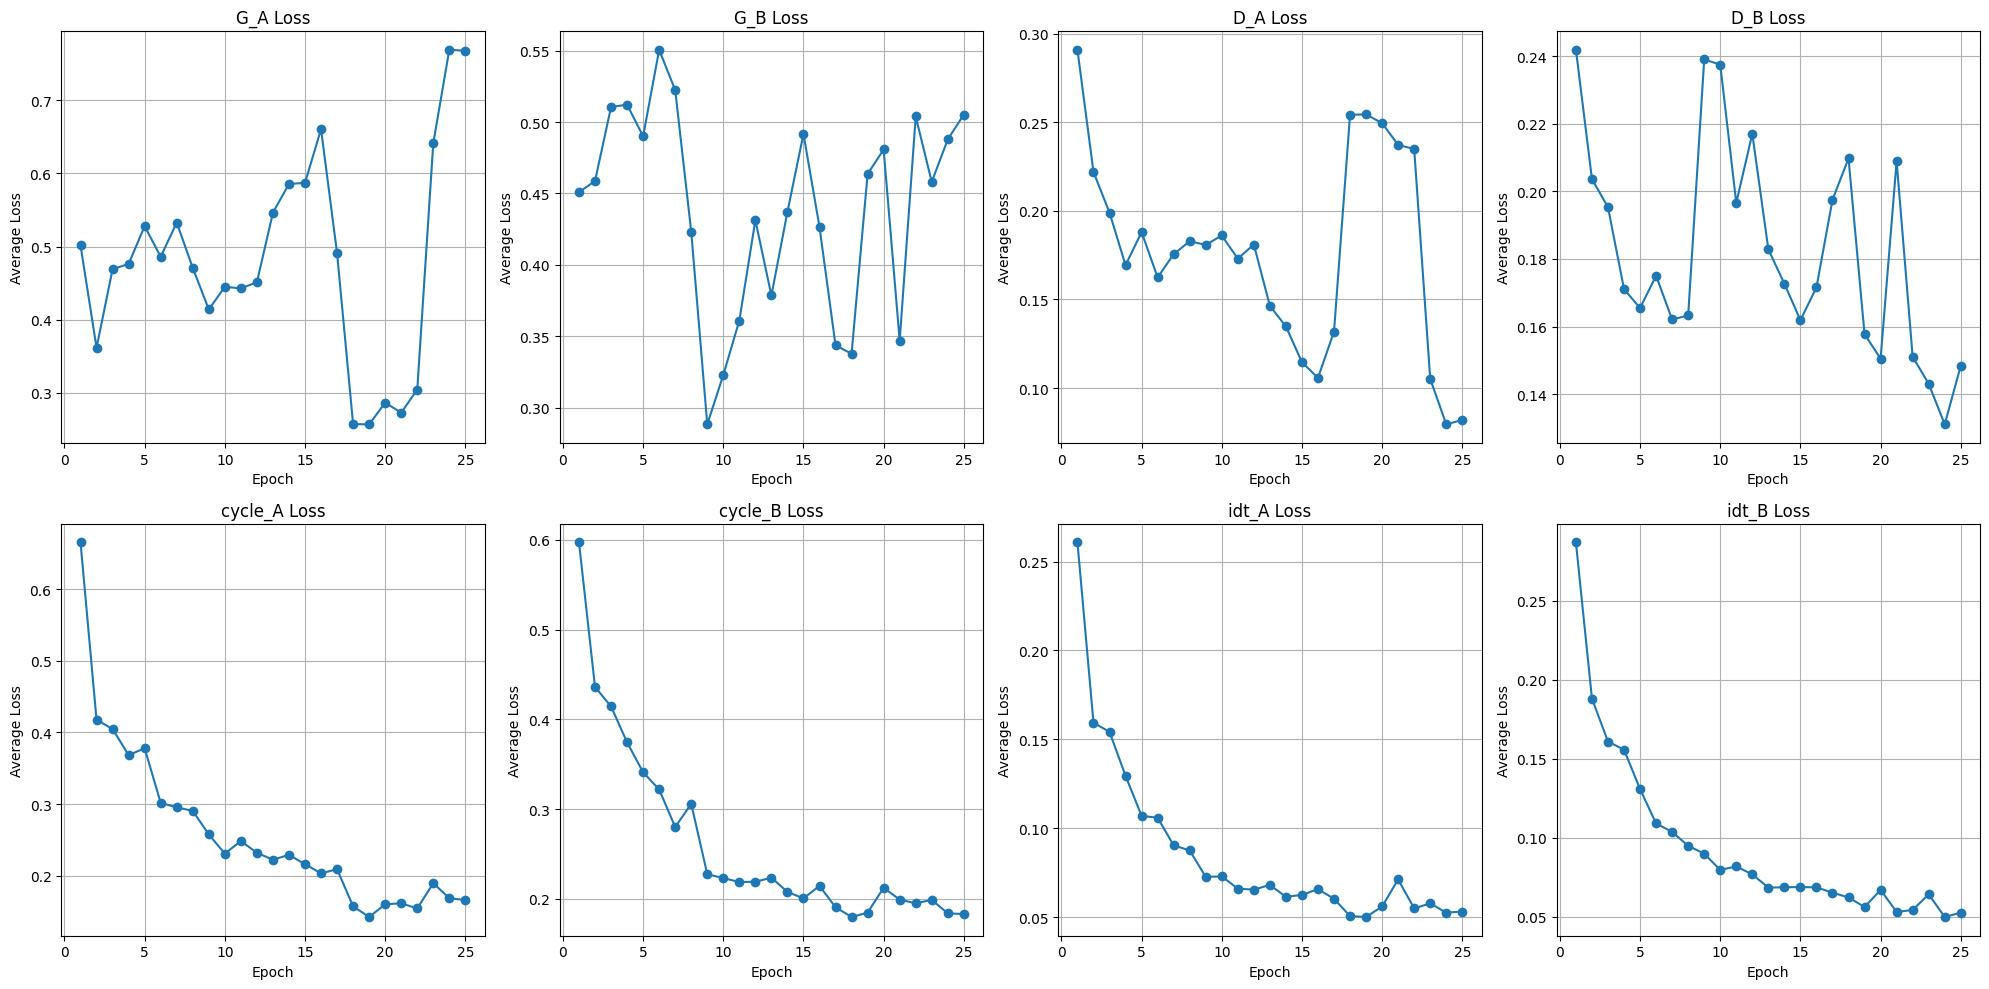

In [65]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

log_file = "/workspace/checkpoints/fashion_cyclegan/loss_log.txt"

# Store losses per epoch
losses_per_epoch = defaultdict(lambda: defaultdict(list))

with open(log_file, 'r') as f:
    for line in f:
        # Extract epoch number
        epoch_match = re.search(r"epoch:\s*(\d+)", line)
        if not epoch_match:
            continue
        epoch = int(epoch_match.group(1))
        
        # Extract losses
        for loss_name in ['G_A', 'G_B', 'D_A', 'D_B', 'cycle_A', 'cycle_B', 'idt_A', 'idt_B']:
            match = re.search(fr"{loss_name}:\s*([-+]?\d*\.\d+|\d+)", line)
            if match:
                losses_per_epoch[epoch][loss_name].append(float(match.group(1)))

# Compute average losses per epoch
avg_losses = defaultdict(list)
epochs = sorted(losses_per_epoch.keys())
for epoch in epochs:
    for loss_name in ['G_A', 'G_B', 'D_A', 'D_B', 'cycle_A', 'cycle_B', 'idt_A', 'idt_B']:
        values = losses_per_epoch[epoch][loss_name]
        avg = sum(values)/len(values) if values else 0
        avg_losses[loss_name].append(avg)

# Plot in a 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
loss_names = ['G_A', 'G_B', 'D_A', 'D_B', 'cycle_A', 'cycle_B', 'idt_A', 'idt_B']

for ax, loss_name in zip(axes.flatten(), loss_names):
    ax.plot(epochs, avg_losses[loss_name], marker='o')
    ax.set_title(f"{loss_name} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average Loss")
    ax.grid(True)

plt.tight_layout()
plt.show()


**Observations:**  

- The **generator loss of B** (sneakers → sandals) and the **discriminator loss of B** are near inverses of each other from the beginning, indicating that the adversarial behavior started immediately.  
- The **generator loss of A** and the **discriminator loss of A** show adversarial characteristics only from around **epoch 13**, suggesting that this mapping took longer to stabilize.  
- The **cycle-consistency** and **identity losses** of both domains decreased gradually, indicating **stable training**.


## **Cycle Reconstruction**

CycleGAN enforces **cycle-consistency**, which ensures that an image translated from one domain to another can be **reconstructed back to its original form**. This is crucial because it ensures that the **structural information and content** are preserved across translations.  

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img_tensor

def show_cycle(image_tensor, G_forward, G_backward):
    with torch.no_grad():
        fake = G_forward(image_tensor)
        cycle = G_backward(fake)

    # de-normalize
    def denorm(tensor):
        return (tensor * 0.5 + 0.5).clamp(0,1)
    
    original = denorm(image_tensor[0]).permute(1,2,0).cpu().numpy()
    fake_img = denorm(fake[0]).permute(1,2,0).cpu().numpy()
    cycle_img = denorm(cycle[0]).permute(1,2,0).cpu().numpy()

    fig, axes = plt.subplots(1,3, figsize=(12,4))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[1].imshow(fake_img)
    axes[1].set_title("Translated")
    axes[2].imshow(cycle_img)
    axes[2].set_title("Cycle Reconstruction")
    for ax in axes: ax.axis('off')
    plt.show()


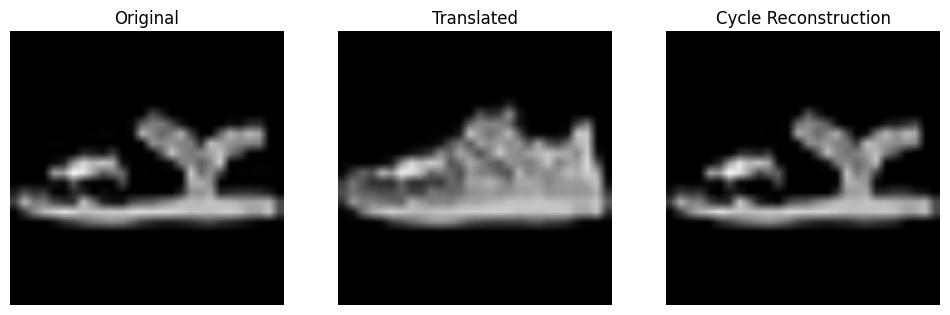

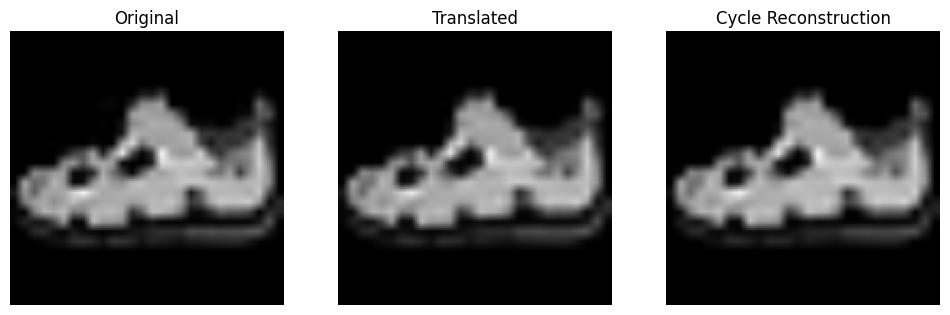

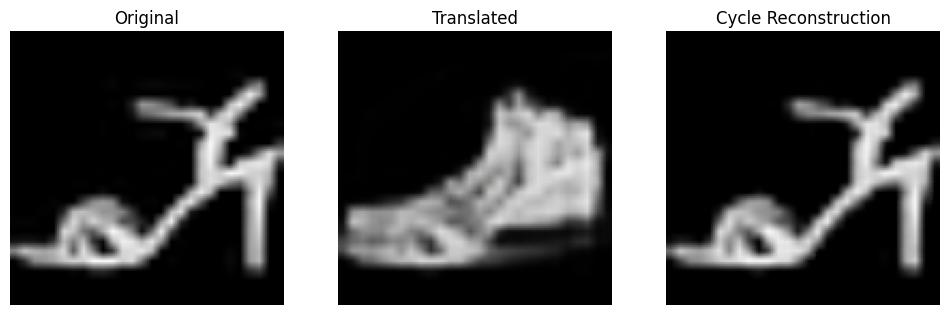

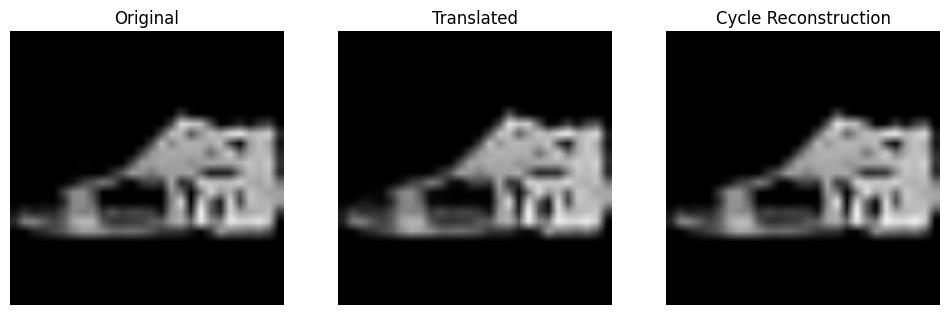

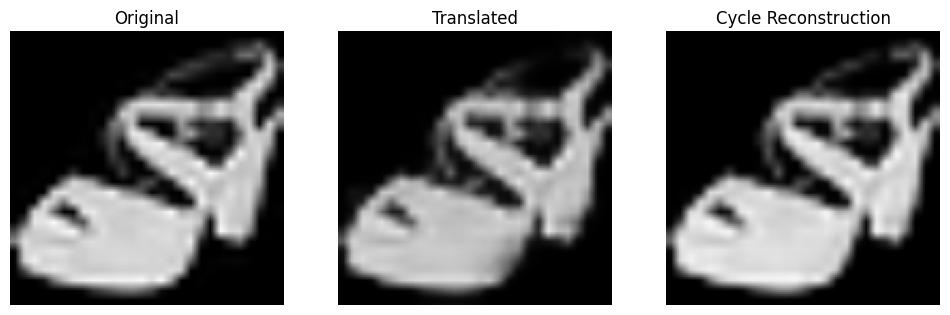

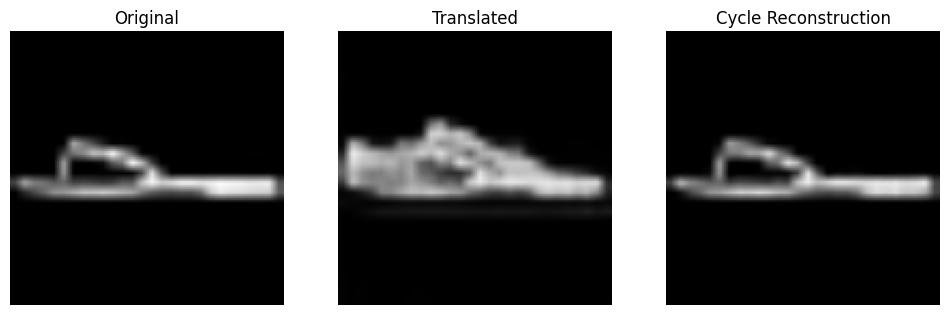

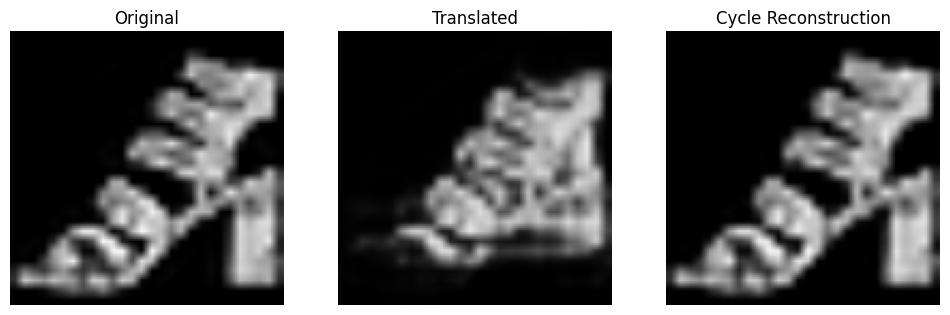

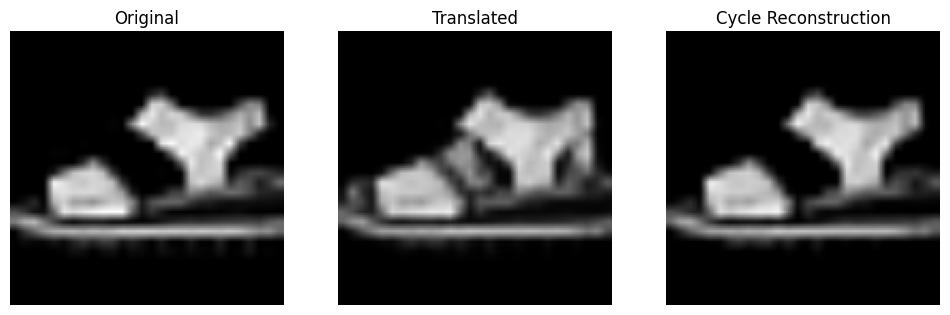

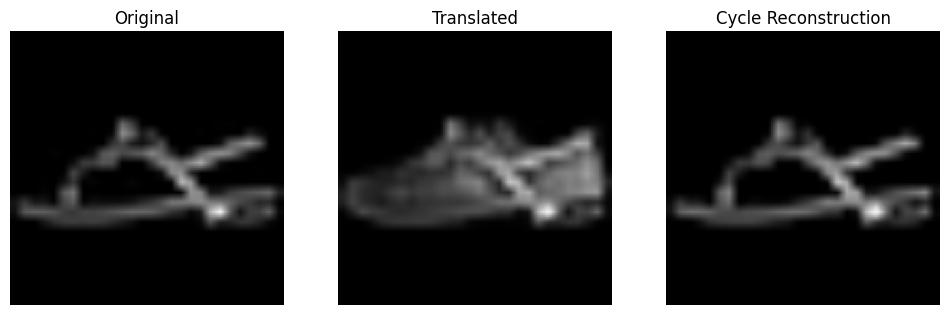

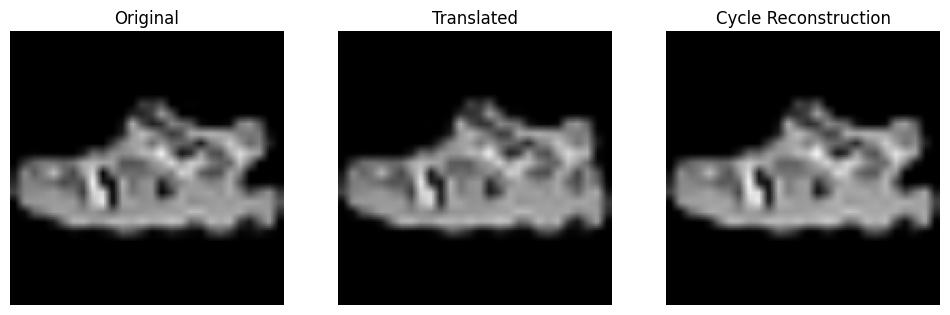

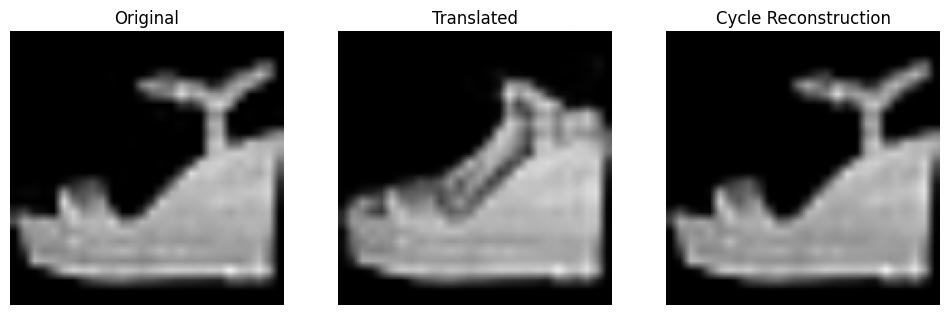

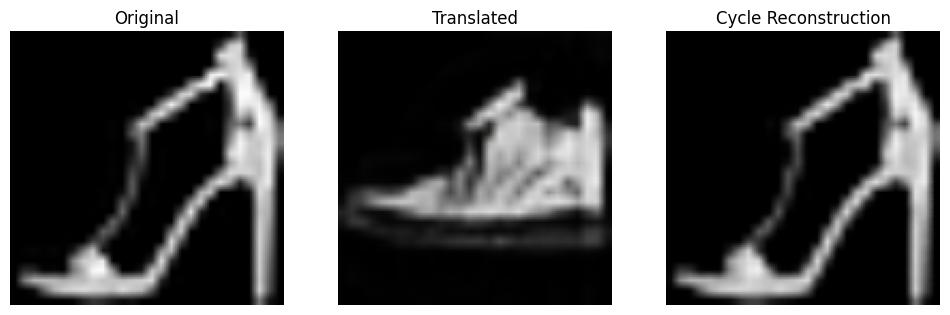

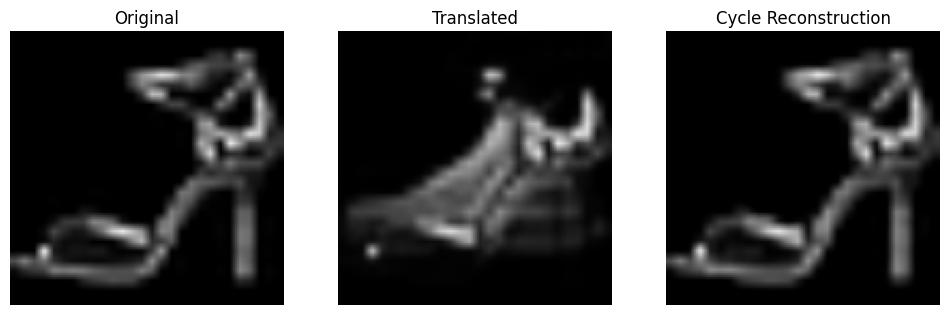

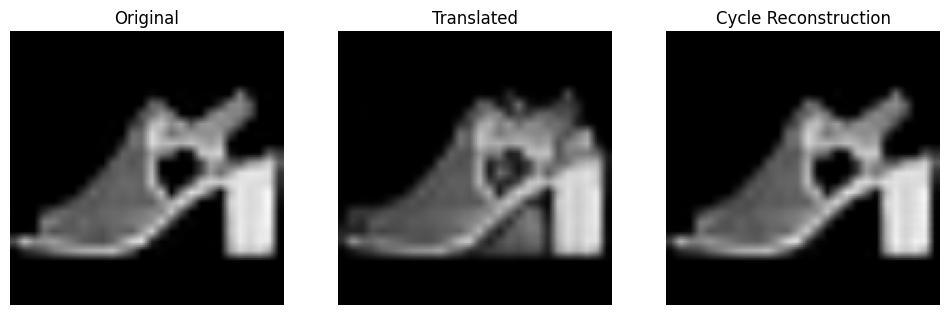

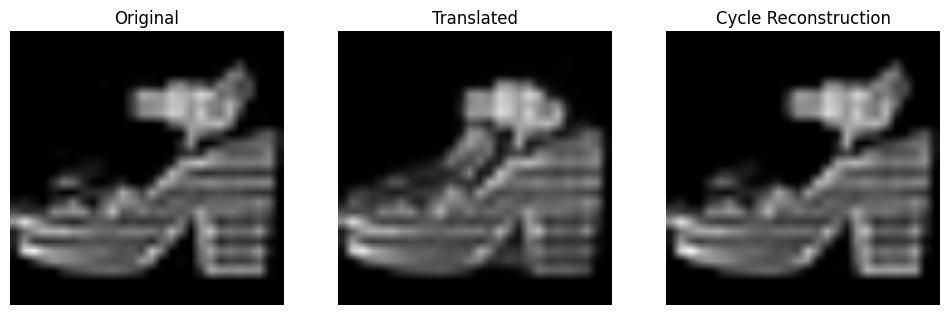

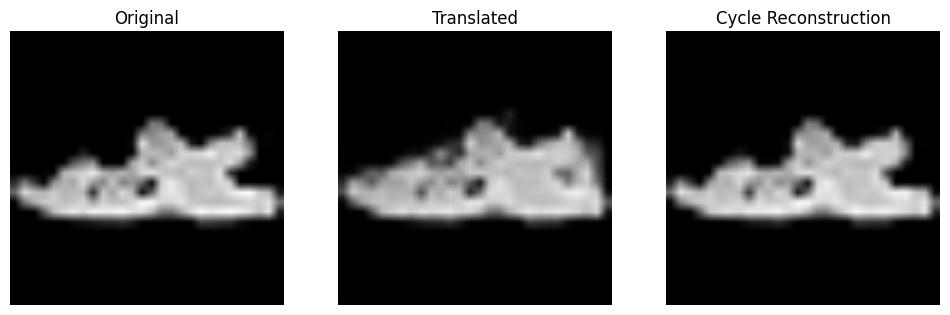

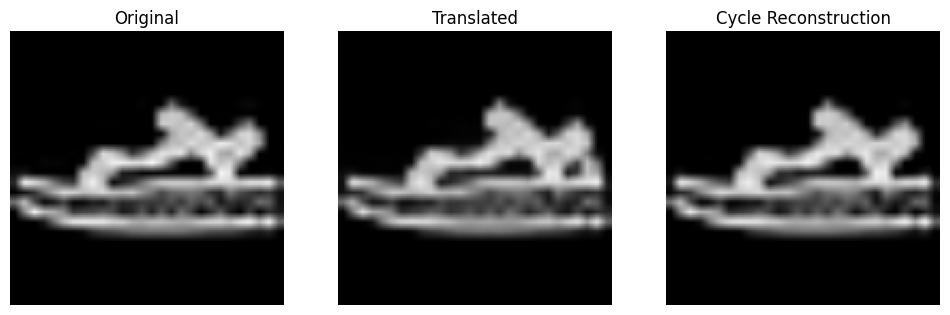

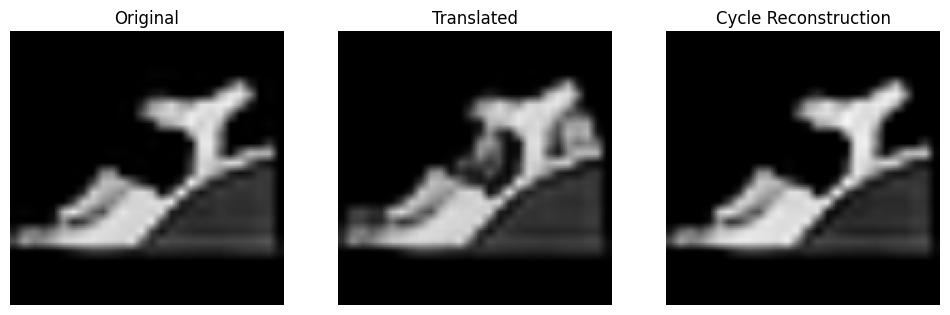

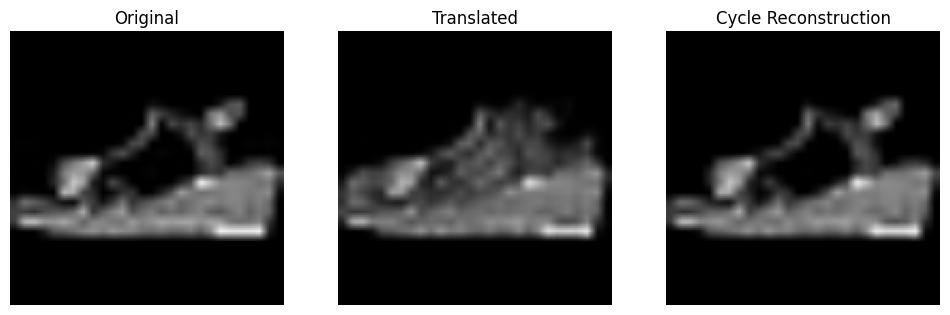

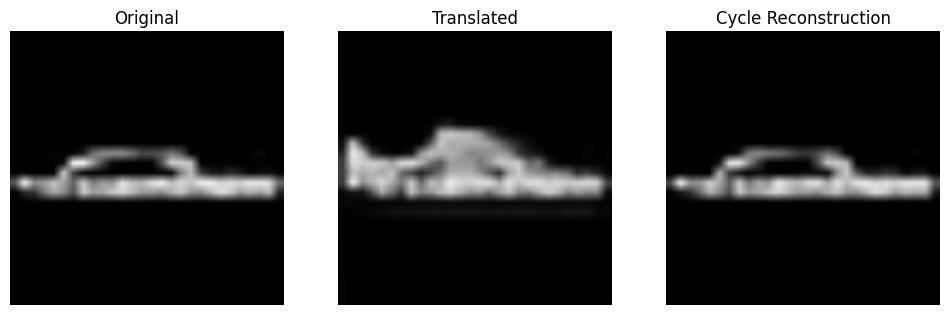

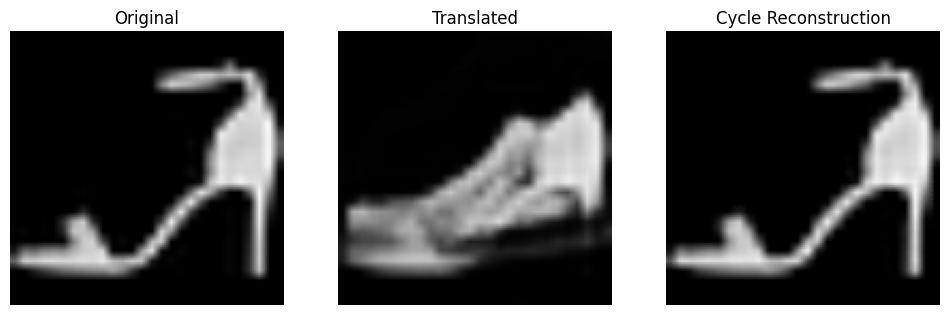

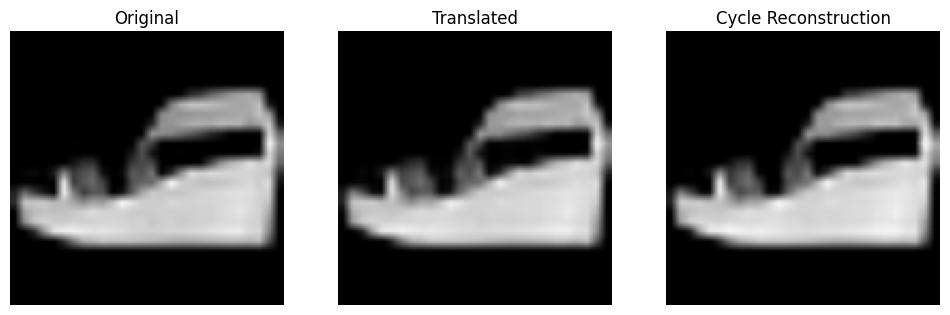

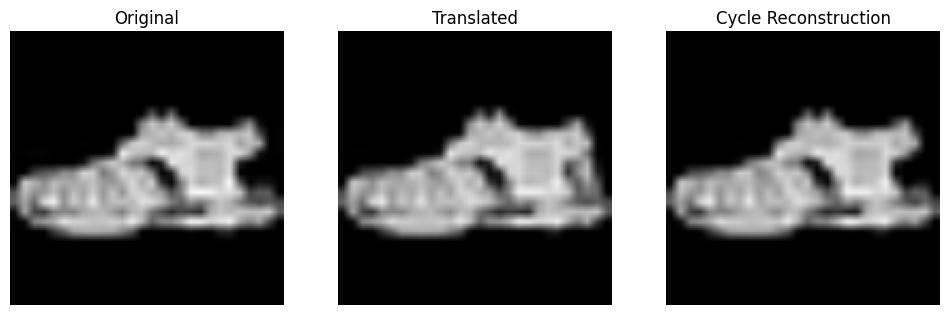

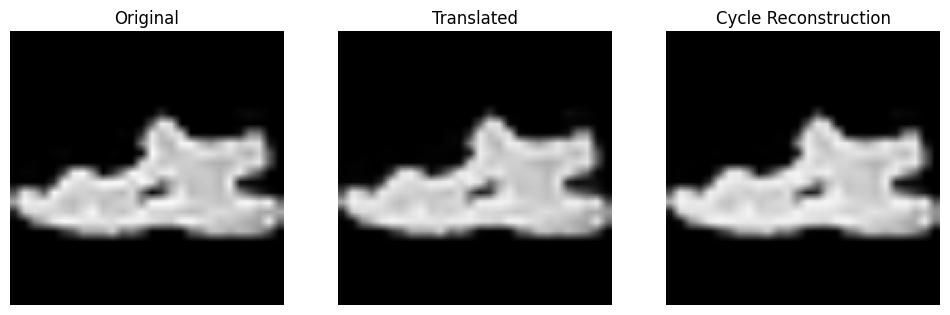

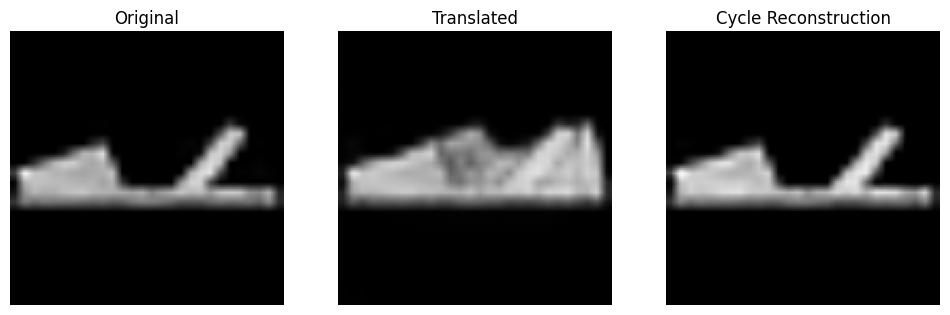

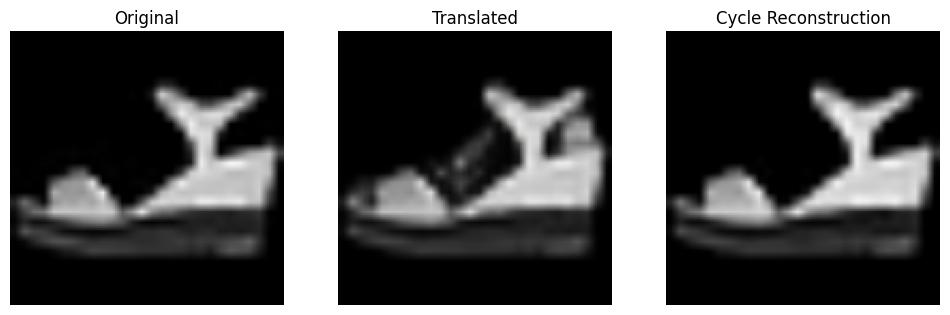

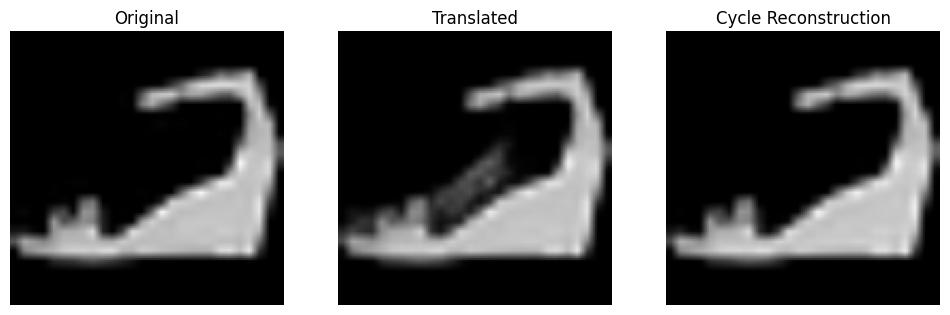

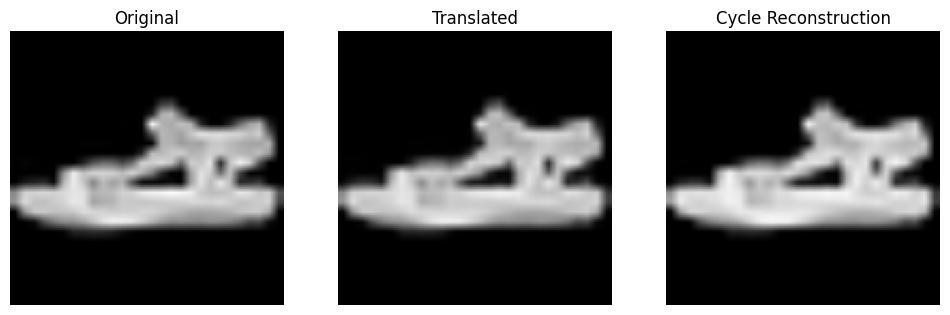

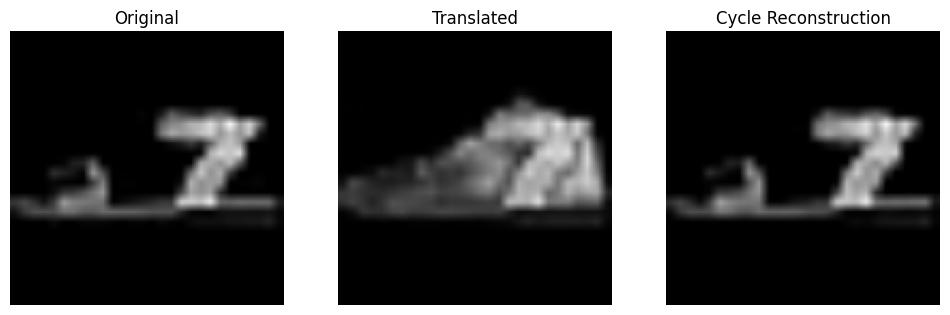

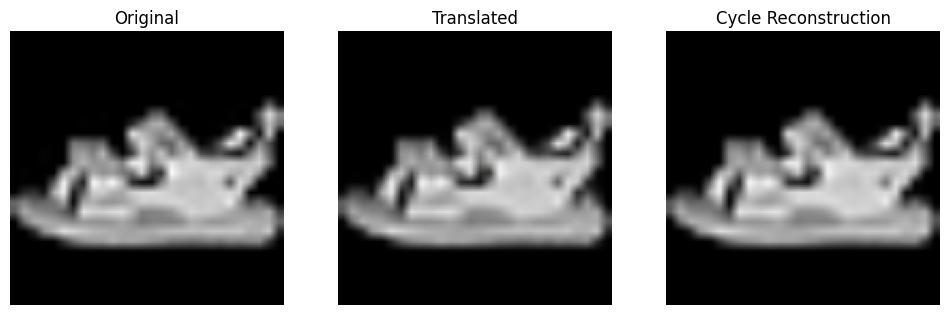

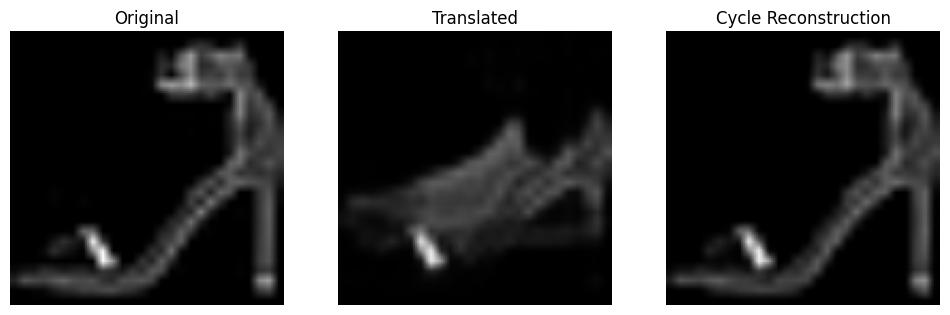

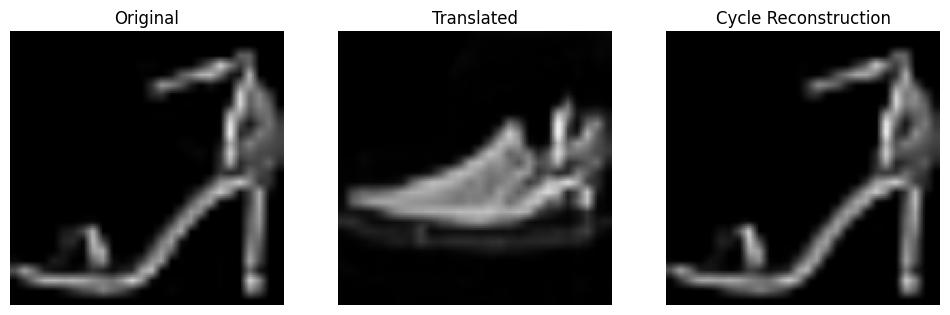

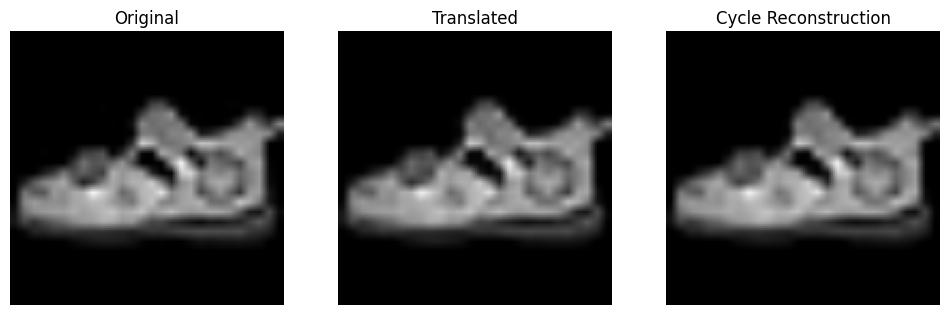

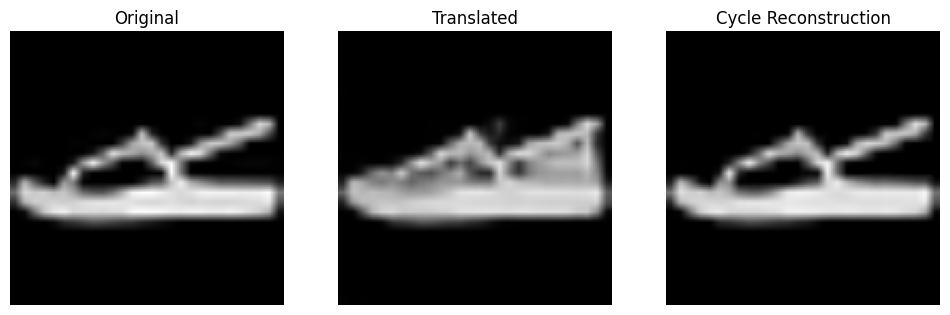

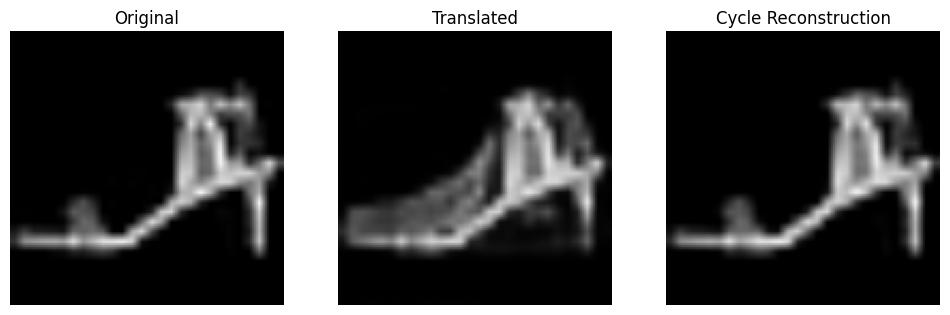

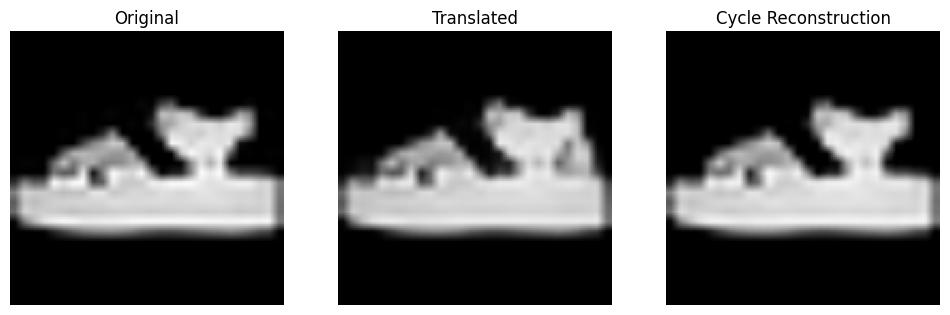

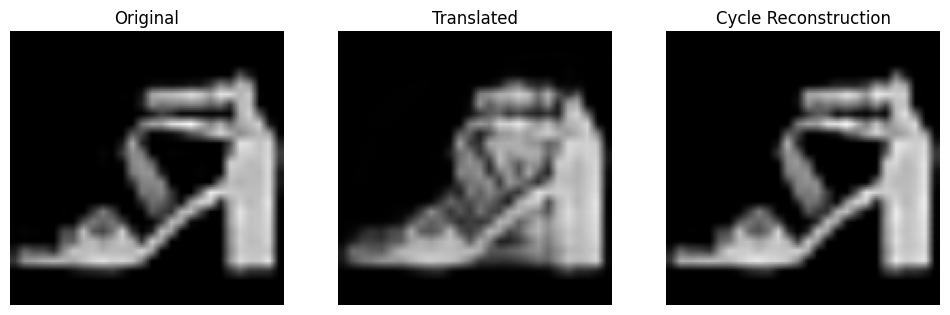

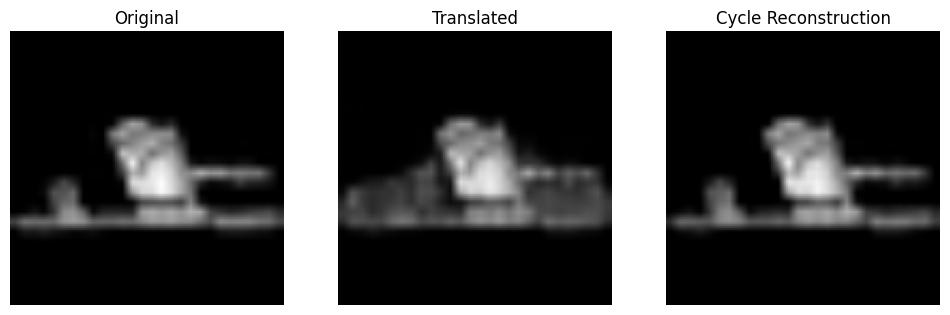

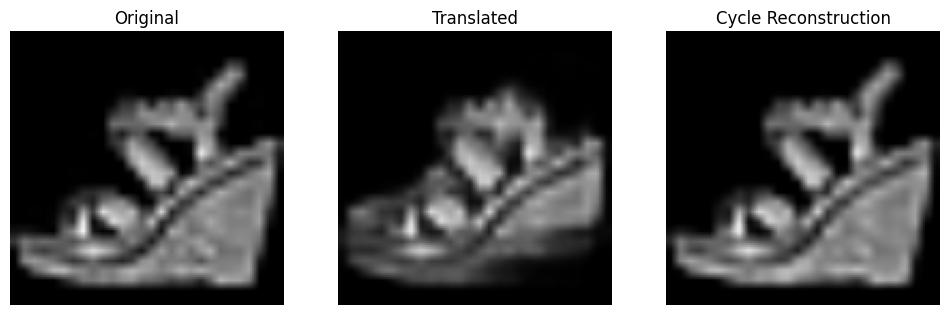

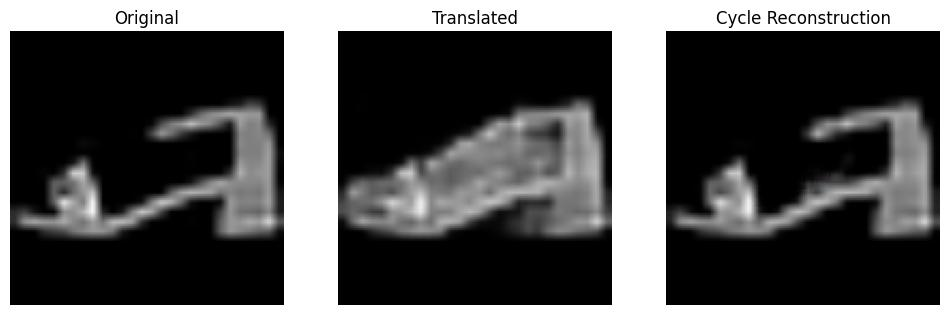

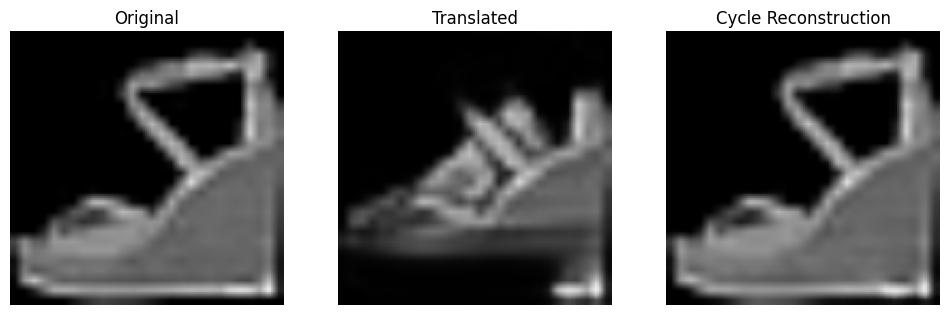

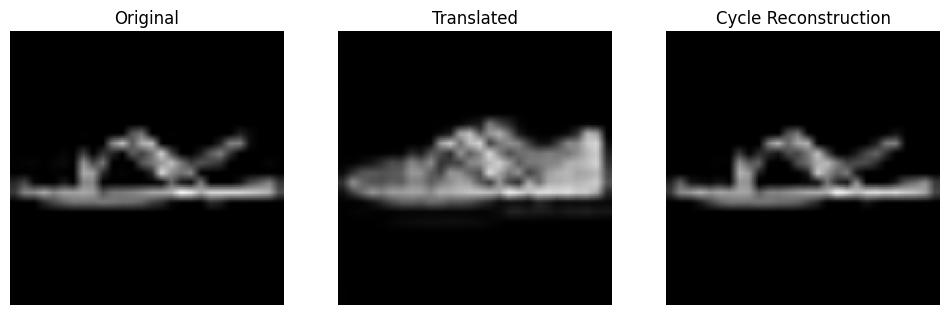

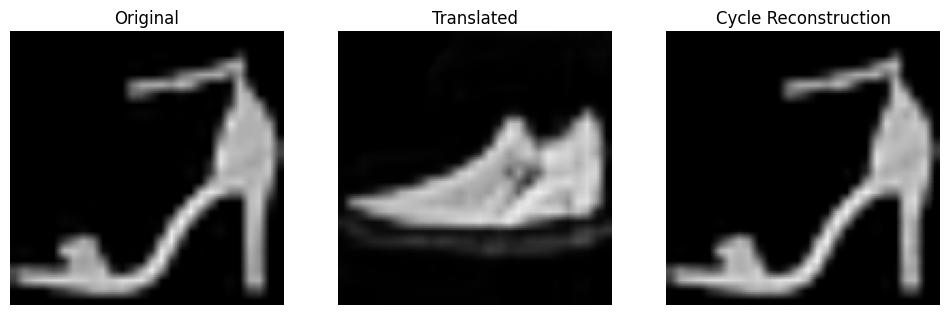

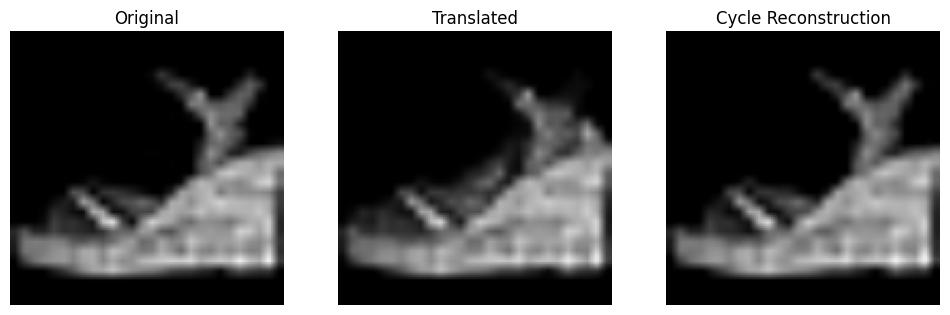

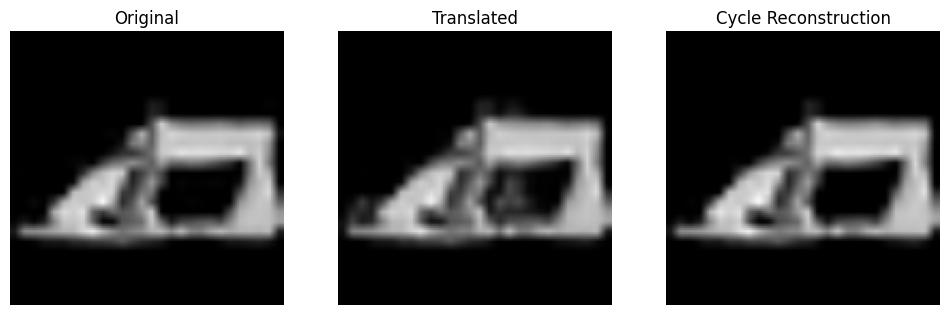

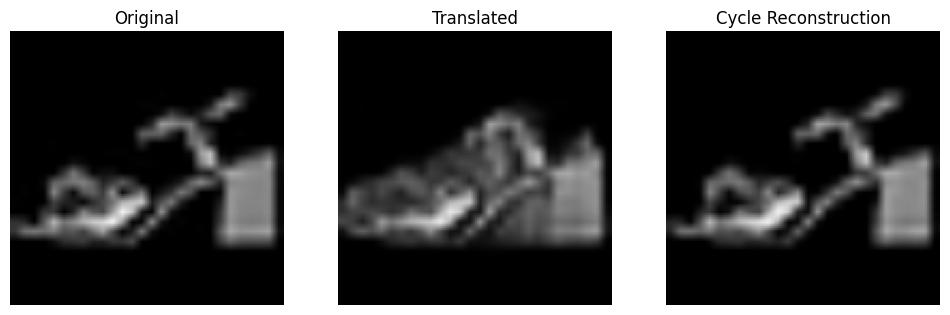

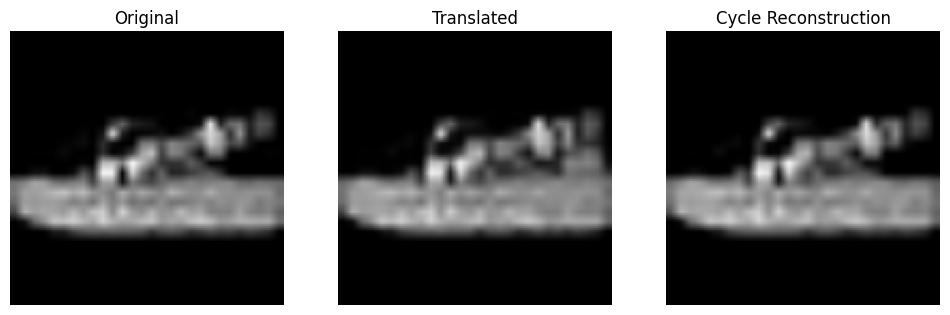

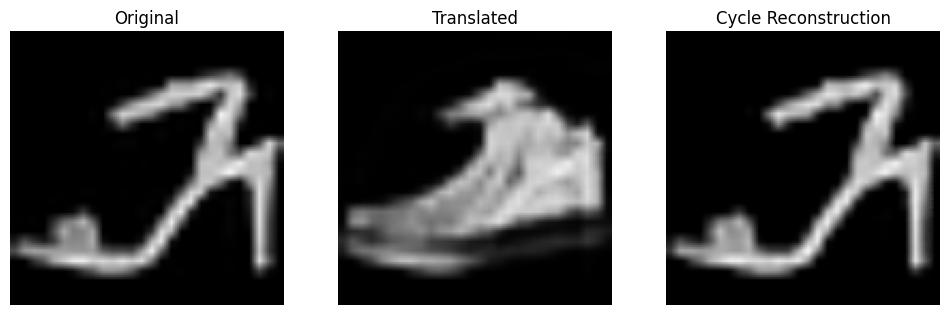

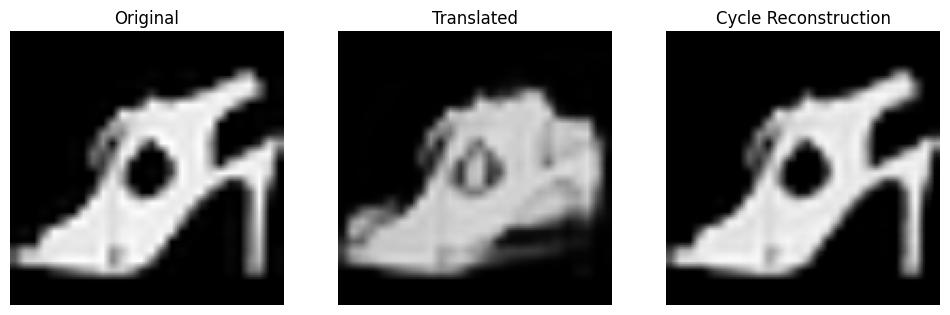

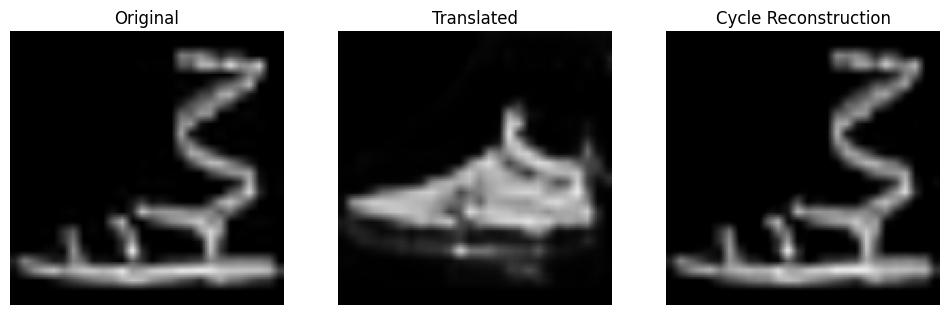

In [40]:
import os
from random import sample

# folder with domain A images
trainA_folder = "/workspace/datasets/fashion/trainA"
all_images = os.listdir(trainA_folder)

# randomly pick 30 images
sample_images = sample(all_images, 50)

# loop through and show cycle reconstructions
for img_name in sample_images:
    img_path = os.path.join(trainA_folder, img_name)
    img_tensor = load_image(img_path)
    show_cycle(img_tensor, G_A, G_B)


**Observations:**  
The translated images from **domain A → B** exhibit **minimal transformations**.  
- Sandals are often converted to **similar sandals** rather than being fully converted into sneakers.  
- For sandals with **pencil or block heels**, the generator introduces **slight wedges** instead of a complete transformation.  
- Sandals with **unusual openings or designs** are often left **unchanged**, indicating that the model struggles with these atypical patterns.


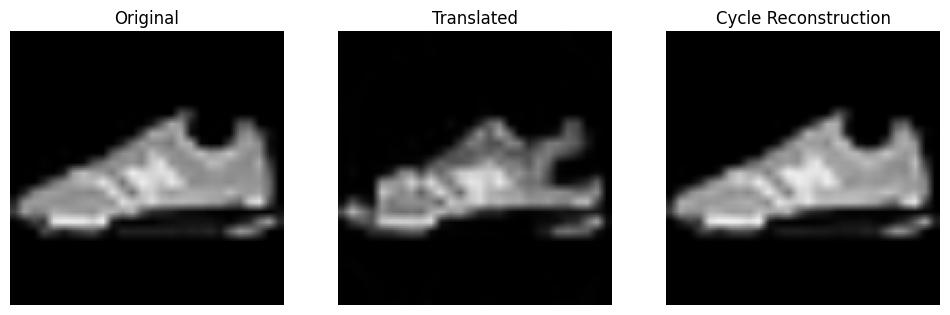

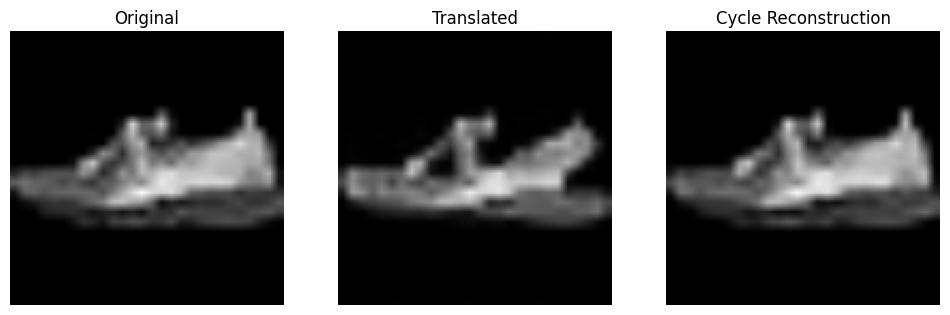

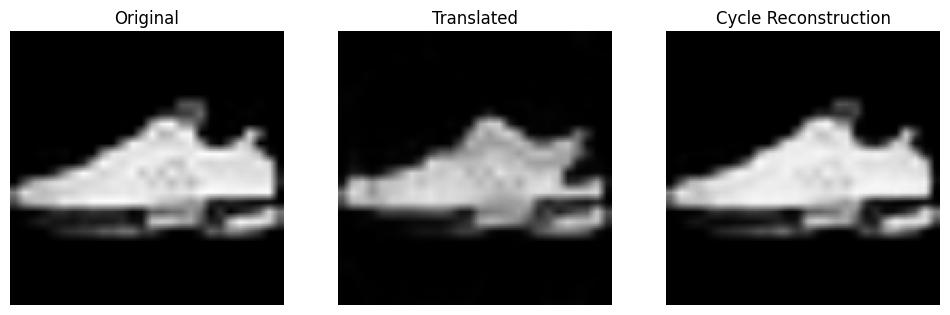

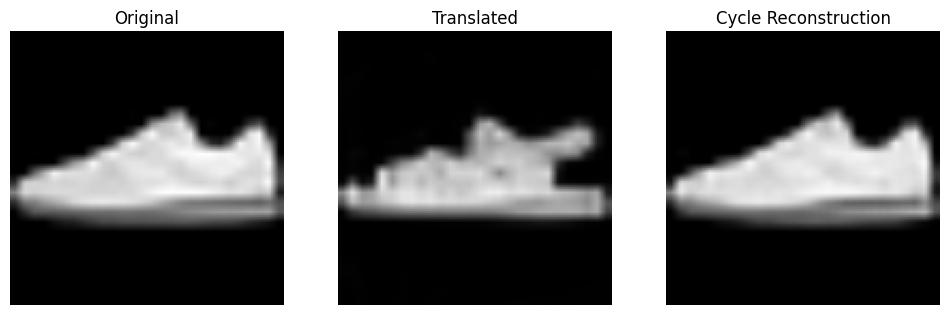

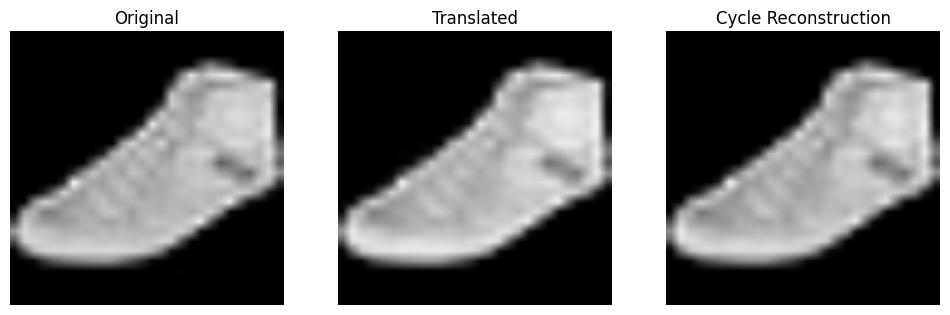

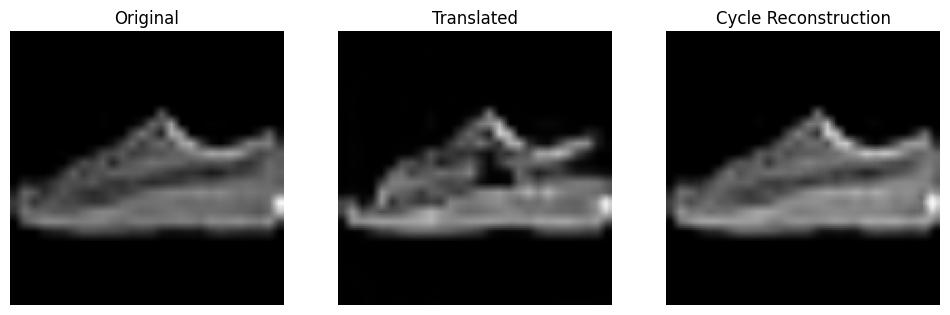

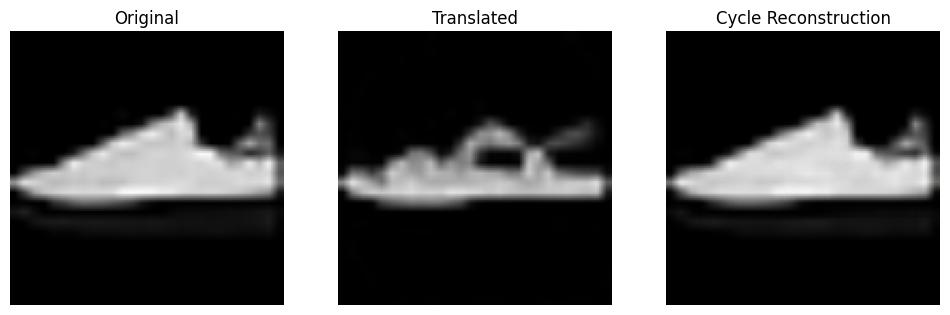

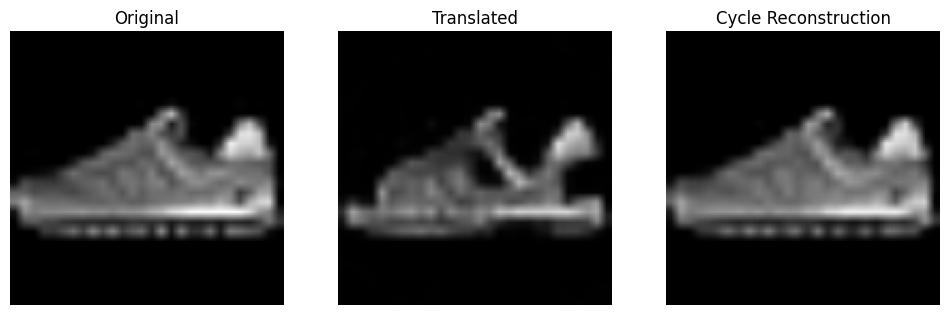

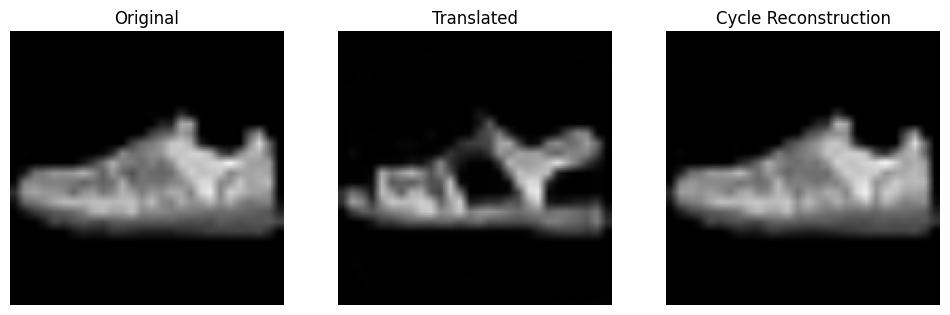

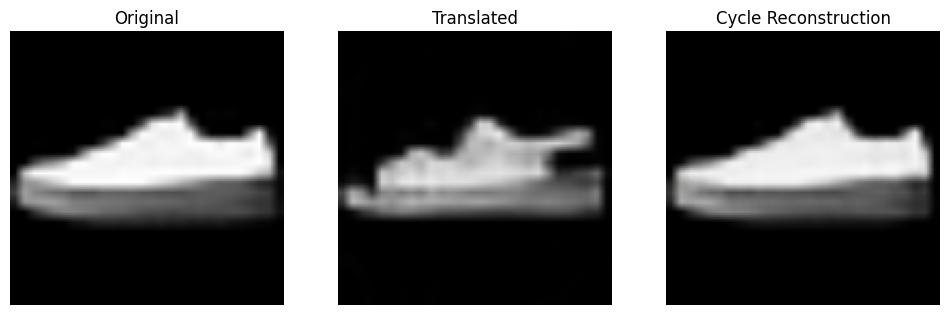

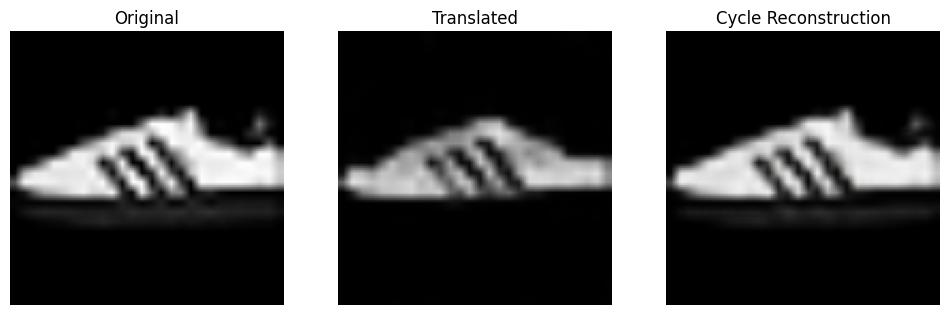

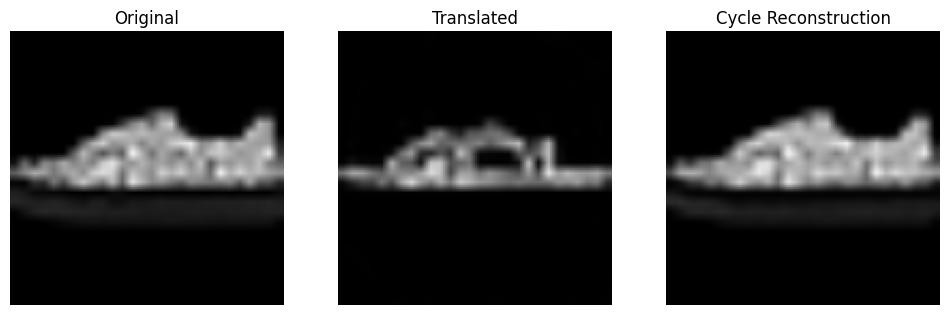

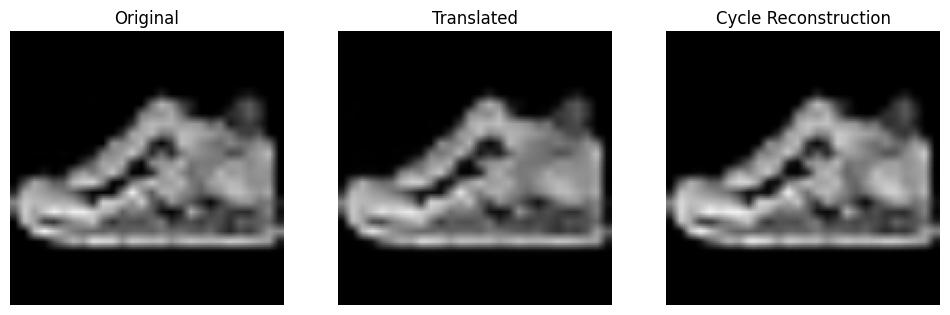

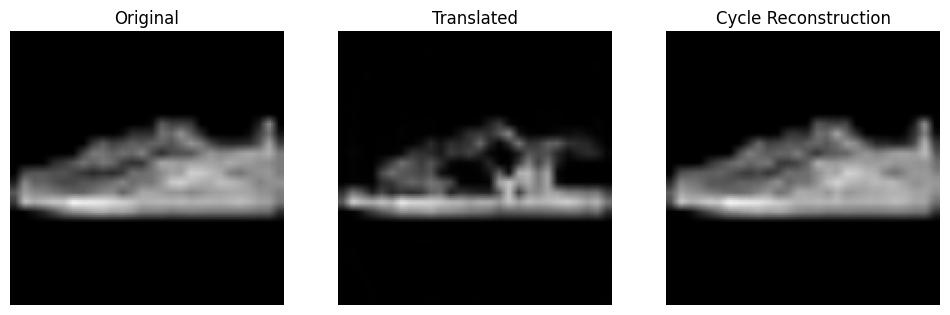

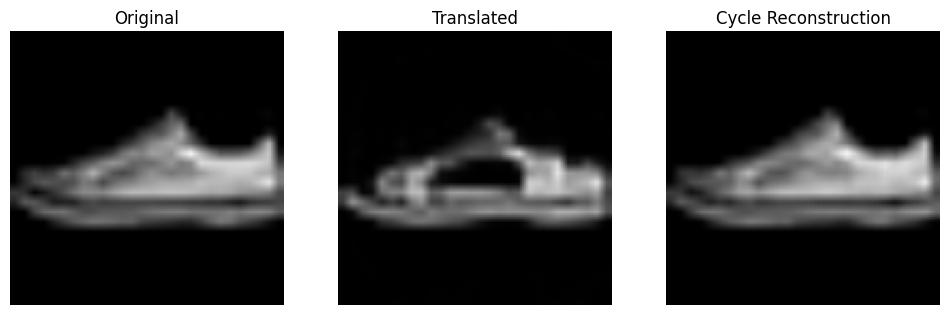

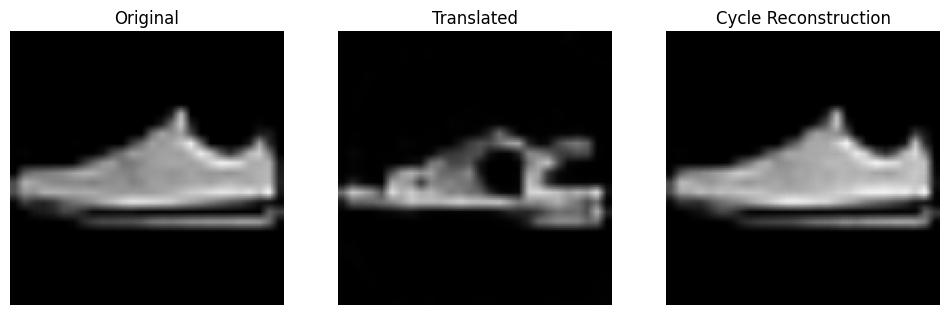

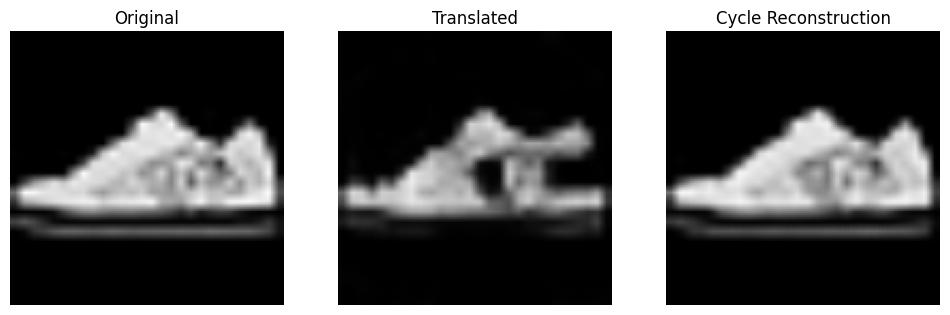

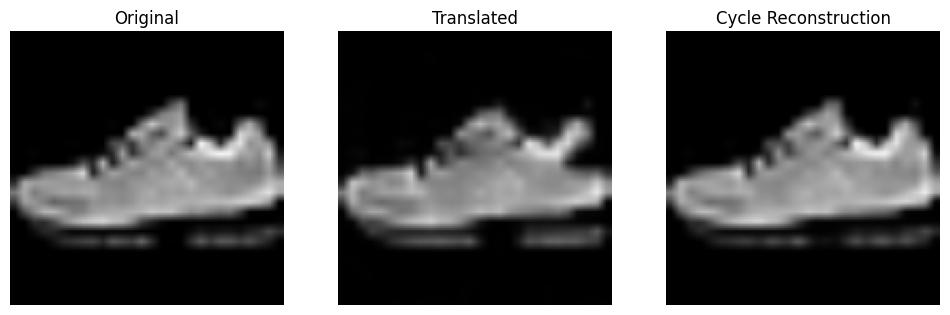

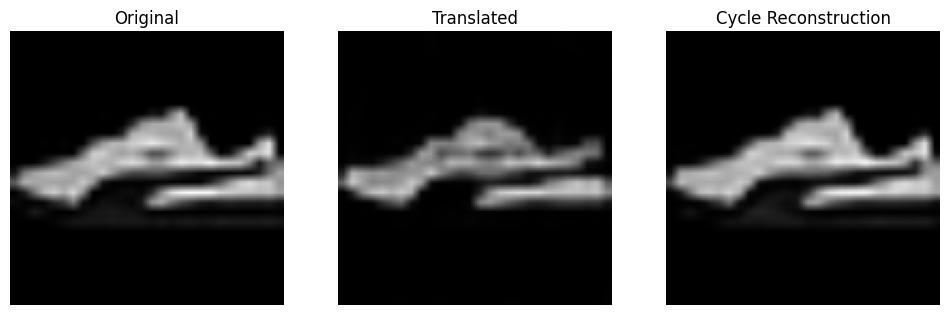

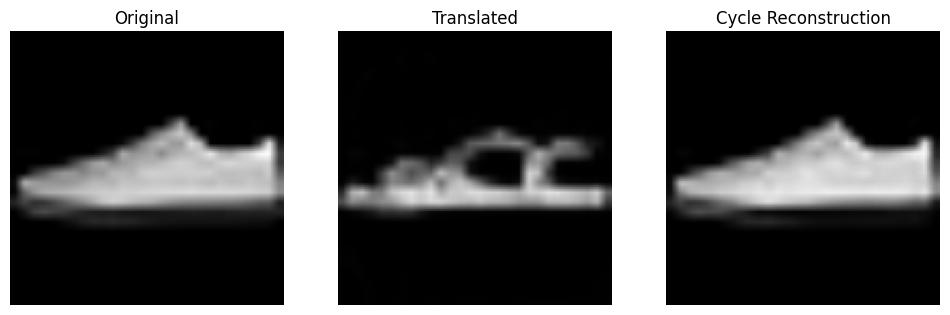

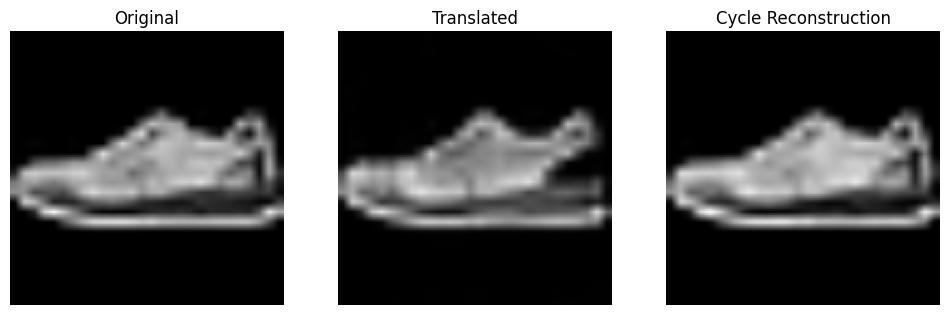

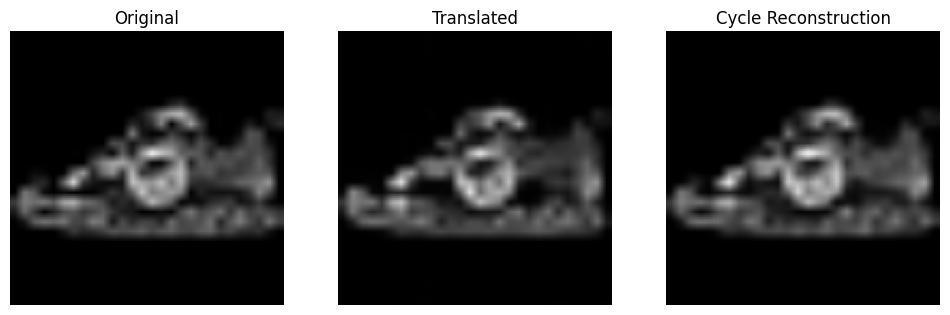

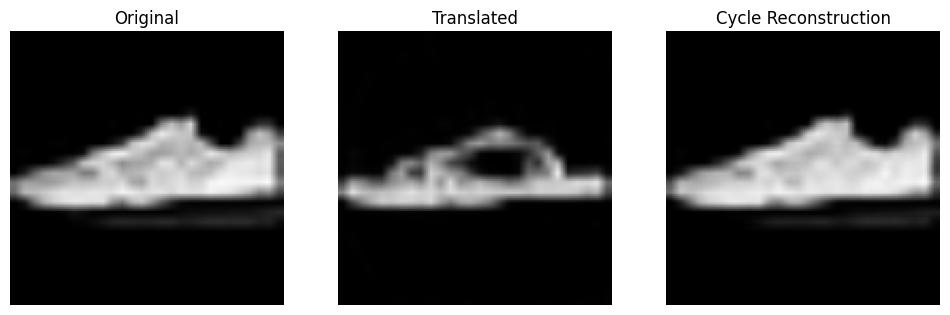

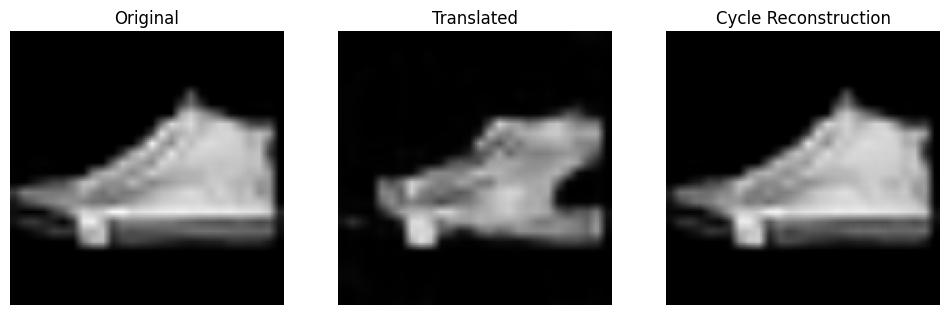

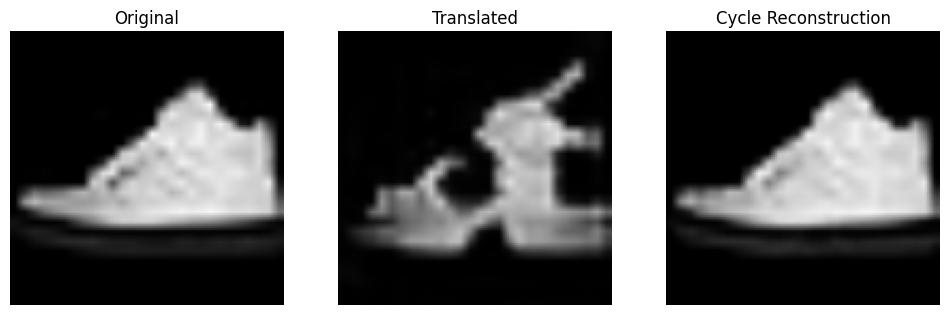

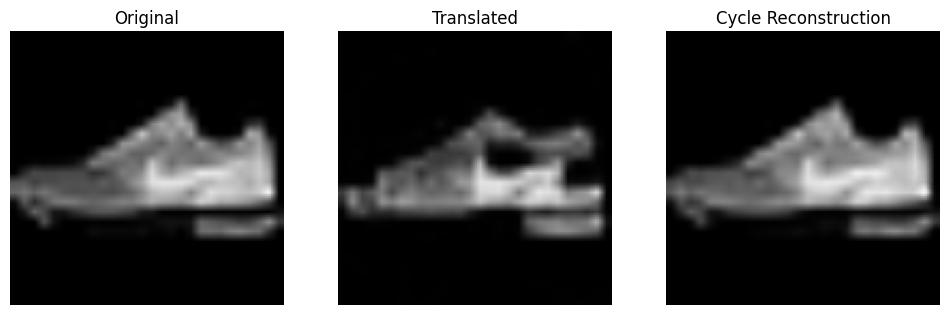

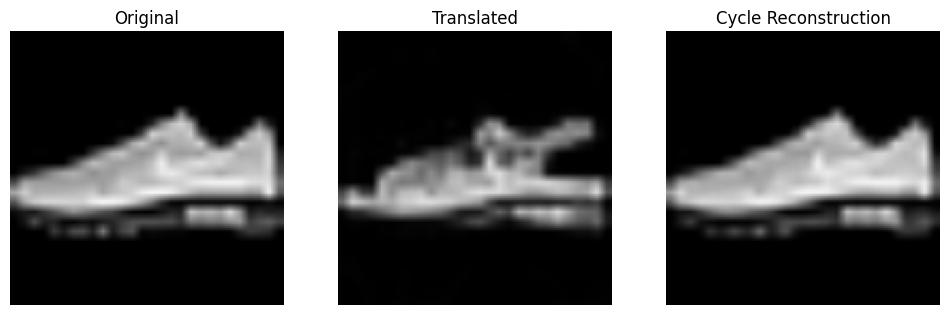

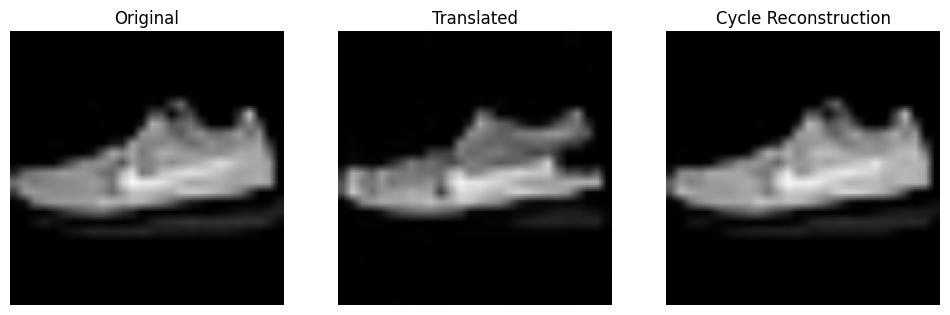

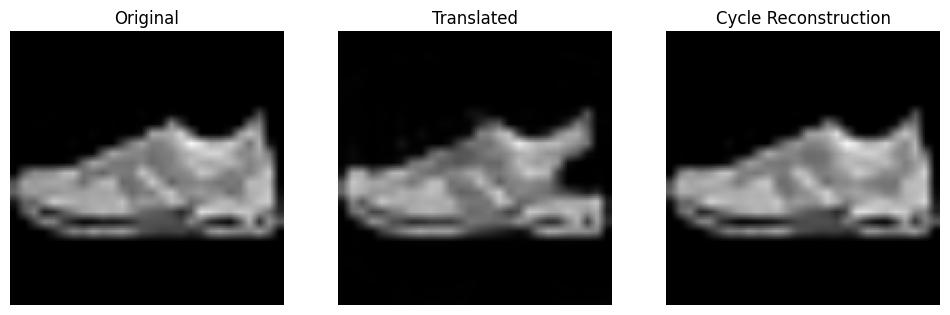

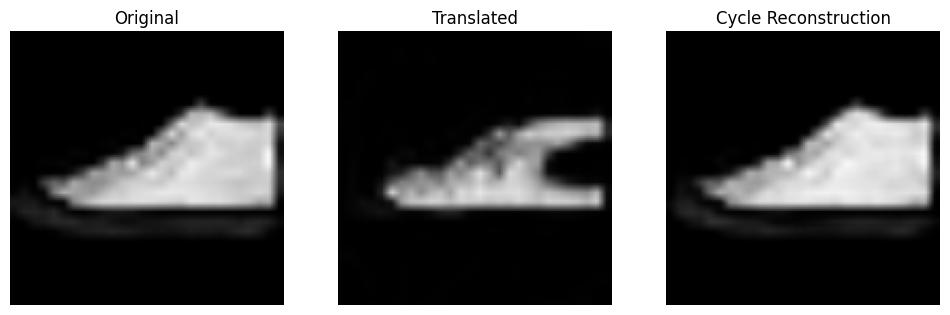

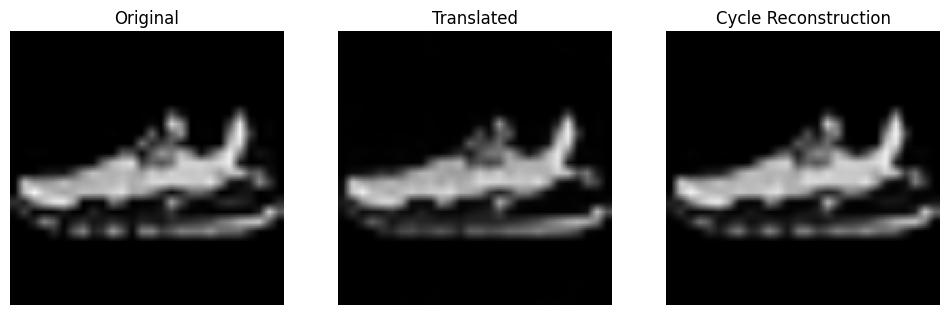

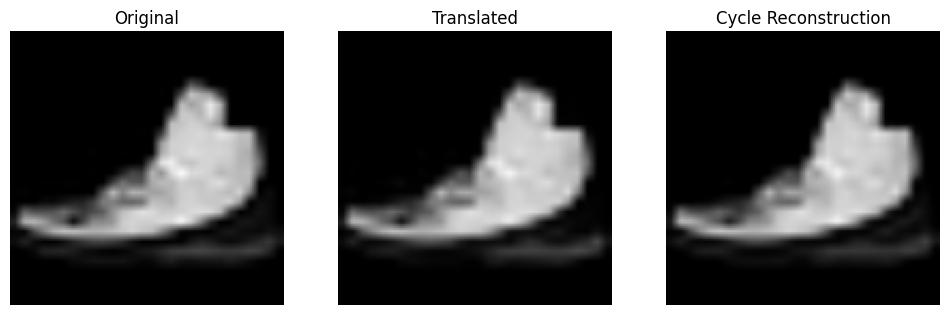

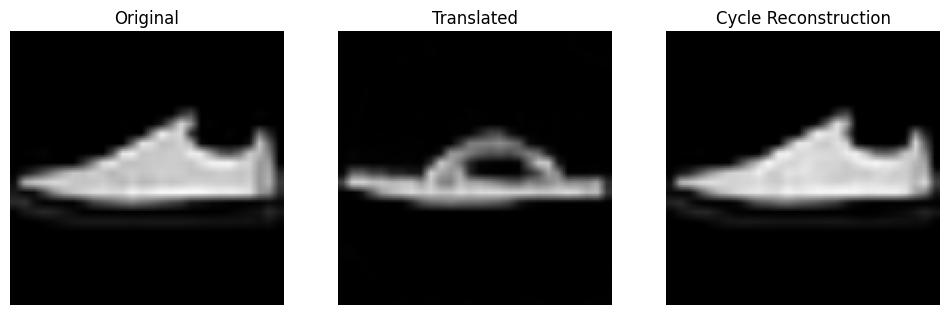

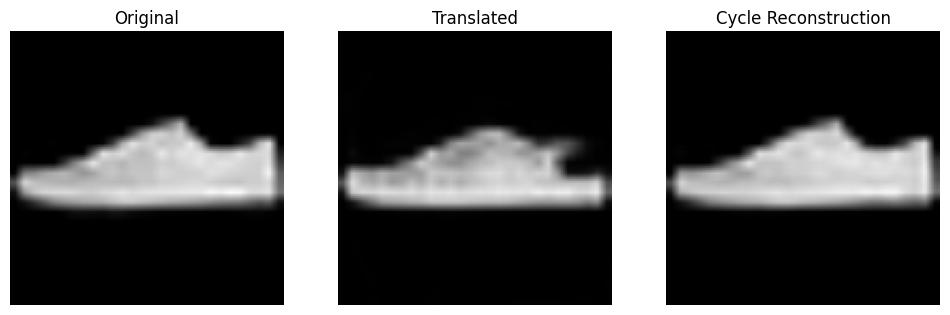

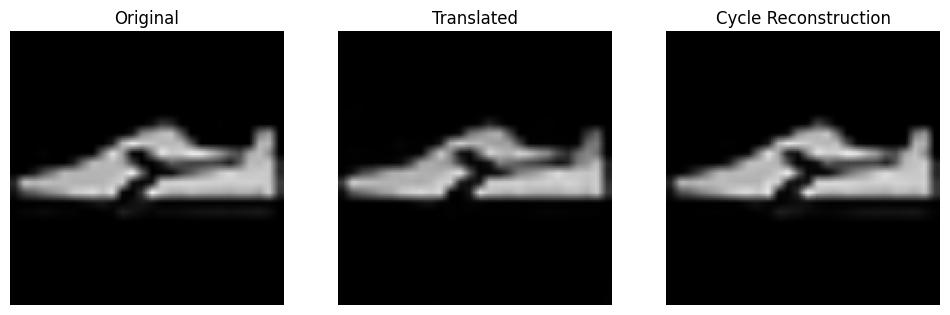

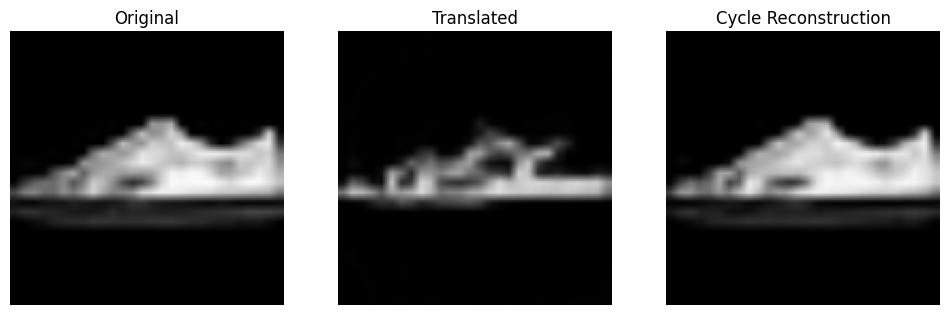

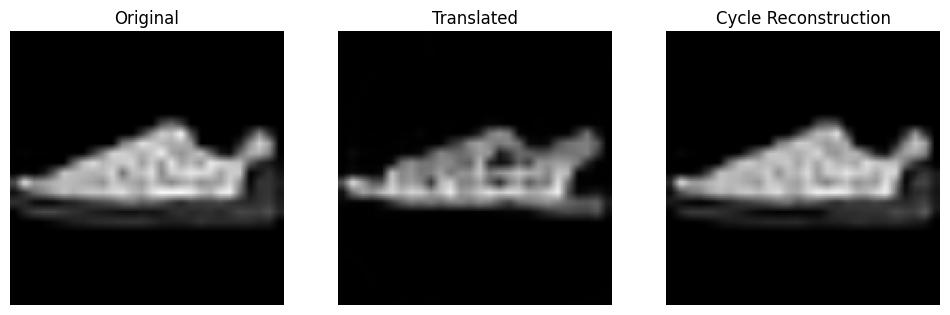

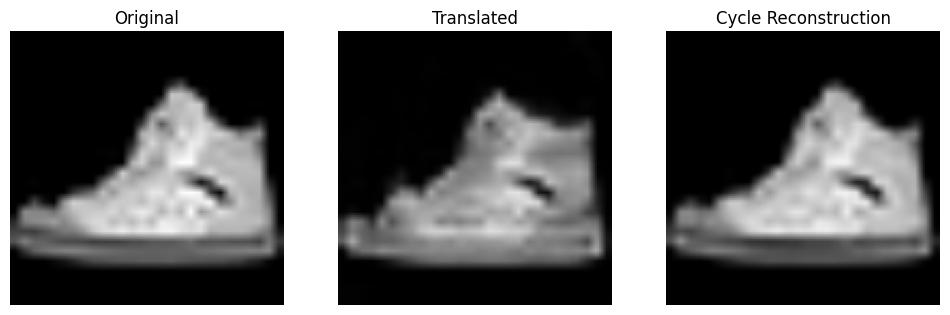

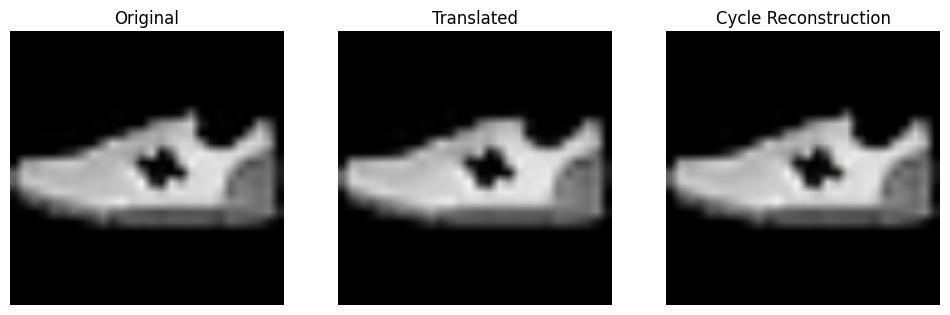

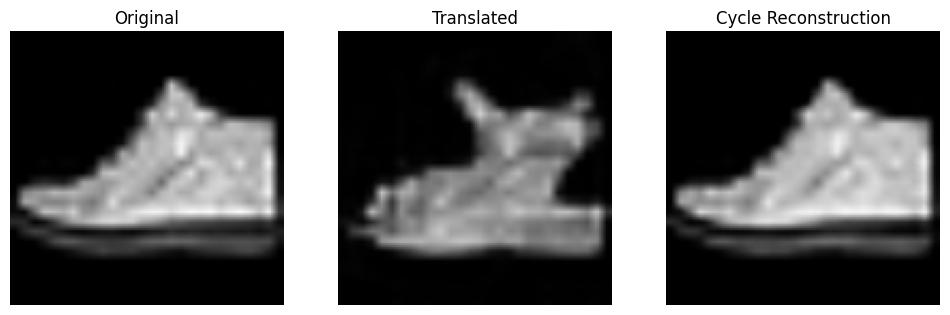

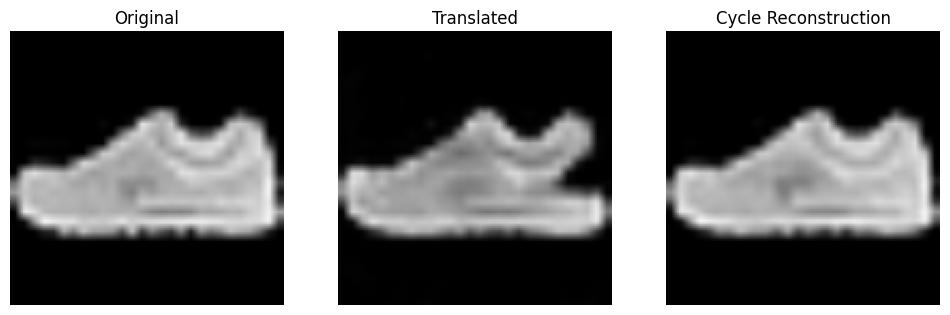

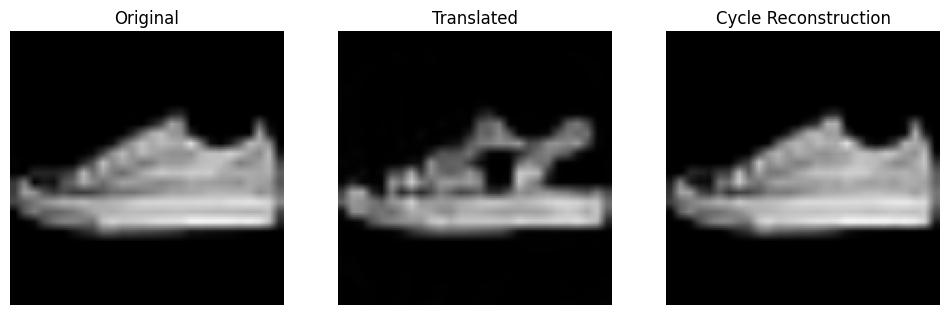

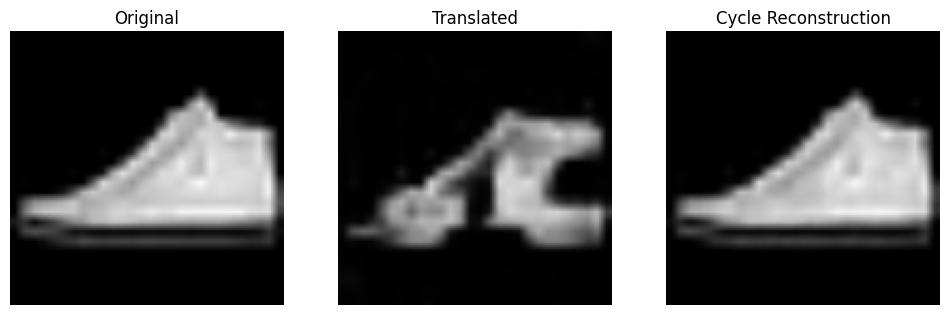

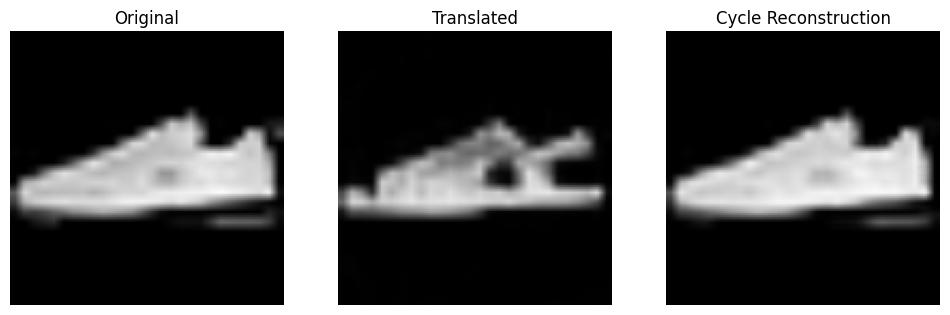

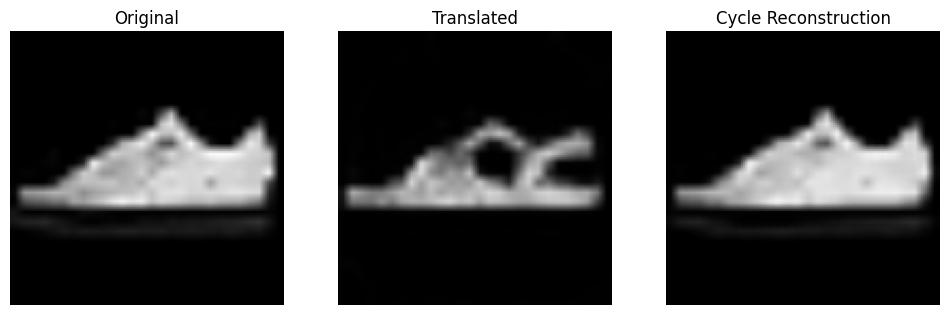

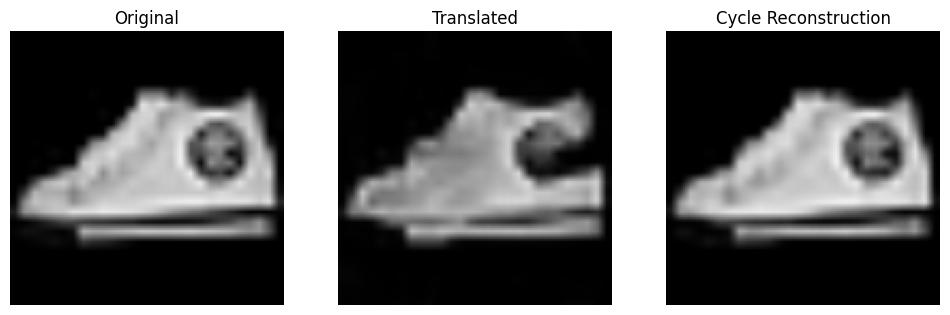

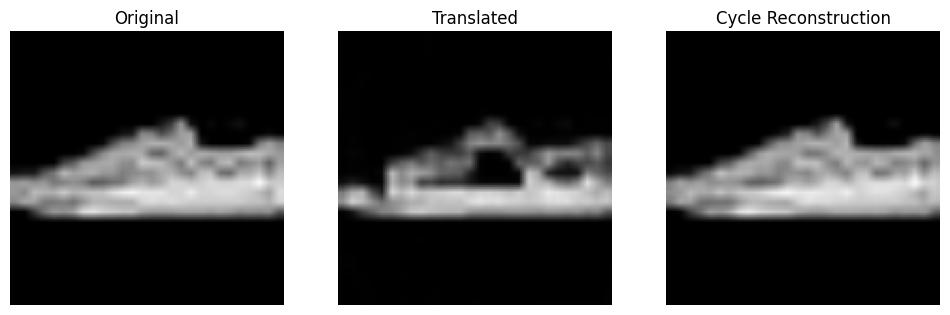

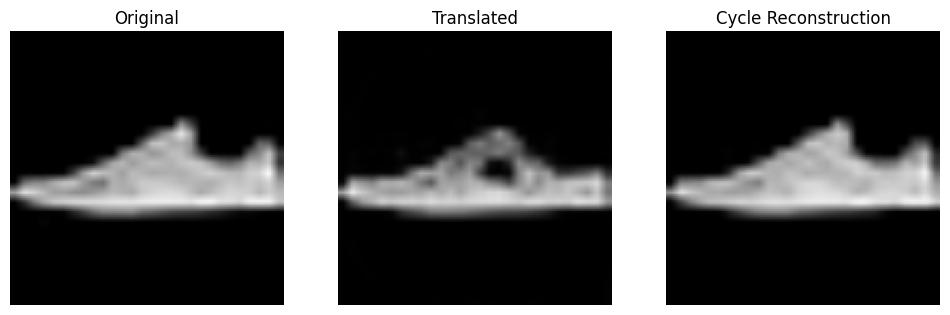

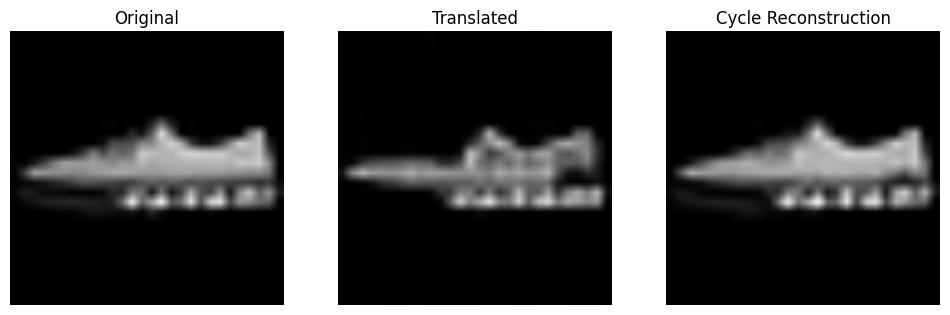

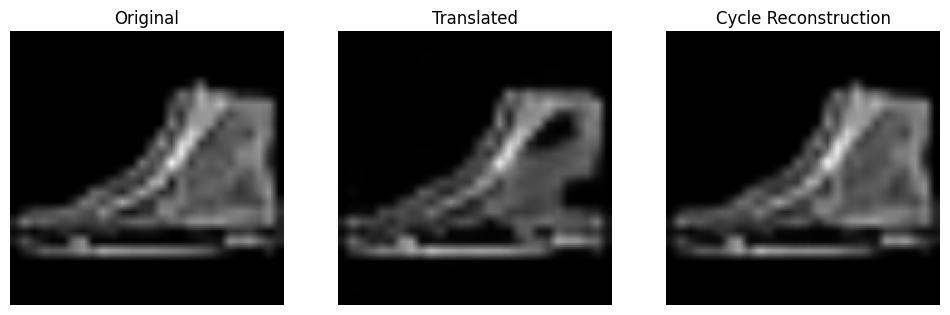

In [42]:
import os
from random import sample

# folder with domain B images
trainB_folder = "/workspace/datasets/fashion/trainB"
all_images = os.listdir(trainB_folder)

# randomly pick 30 images
sample_images = sample(all_images, 50)

# loop through and show cycle reconstructions
for img_name in sample_images:
    img_path = os.path.join(trainB_folder, img_name)
    img_tensor = load_image(img_path)
    show_cycle(img_tensor, G_B, G_A)


**Observations:**  
The translated images from **domain B → A** also exhibit **minimal transformations**.  
- Many sneakers, including **logo-branded shoes**, are often **left unaltered**.  
- Some sneakers are converted into **unconventional sandals**, indicating that the generator struggles to produce realistic or consistent mappings for certain types of shoes.


## **Identity Mapping**

The following visualization passes an input image through the generator of the **opposite domain** to check whether the generator **preserves the image when it is already in the target domain**. This demonstrates the effect of the **identity loss** which encourages minimal changes for images that do not require translation.


**Overall Observation:**  
Both translation directions highlight that the generators have **over-prioritized cycle consistency over actual translation**.  
- This behavior may be due to the **low-resolution images**, which limit the generator’s ability to produce diverse and creative transformations.  
- Using a **higher-resolution dataset** could potentially lead to **more realistic and creative translations**, as the model would have richer information to learn from.


In [93]:
def show_identity(image_tensor, G):
    with torch.no_grad():
        identity = G(image_tensor)

    # de-normalize
    def denorm(tensor):
        return (tensor * 0.5 + 0.5).clamp(0,1)

    original = denorm(image_tensor[0]).permute(1,2,0).cpu().numpy()
    idt_img = denorm(identity[0]).permute(1,2,0).cpu().numpy()

    fig, axes = plt.subplots(1,2, figsize=(8,4))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[1].imshow(idt_img)
    axes[1].set_title("Identity Mapping")
    for ax in axes: ax.axis('off')
    plt.show()


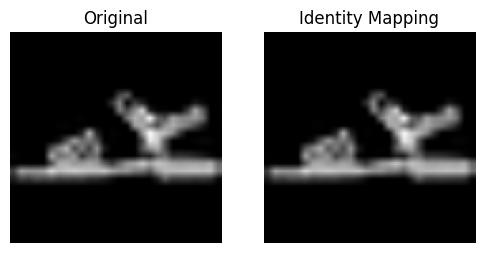

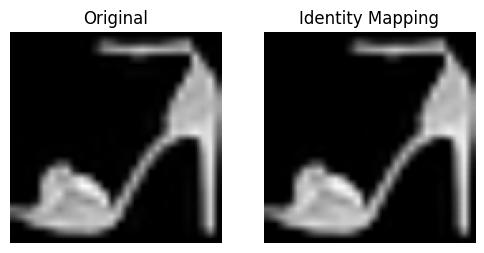

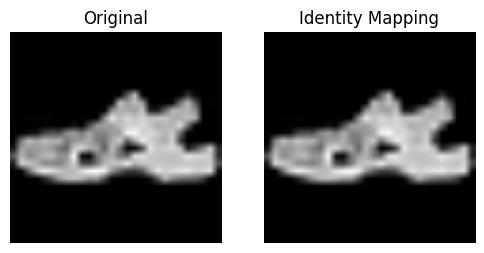

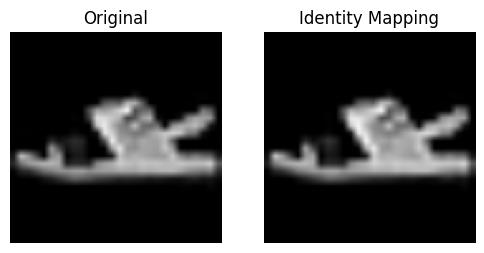

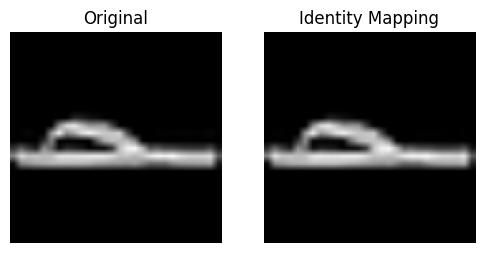

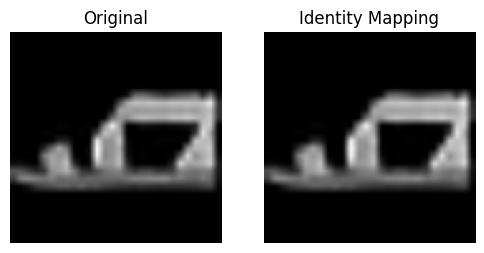

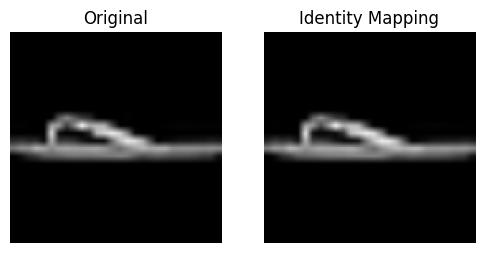

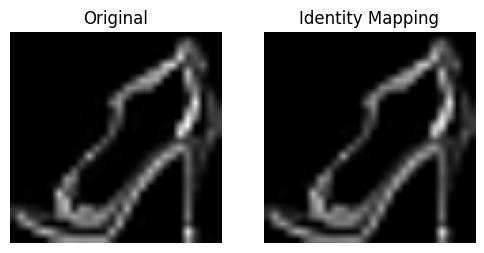

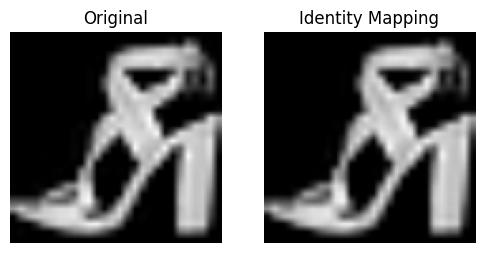

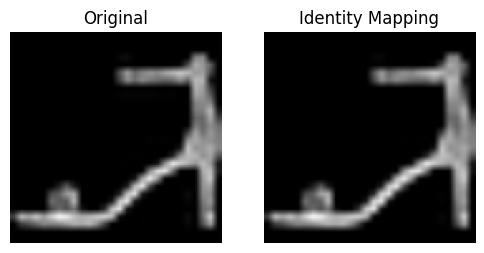

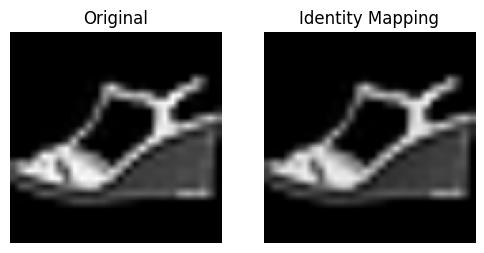

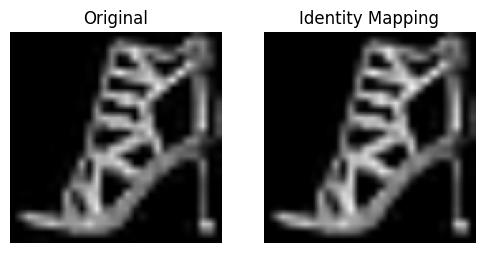

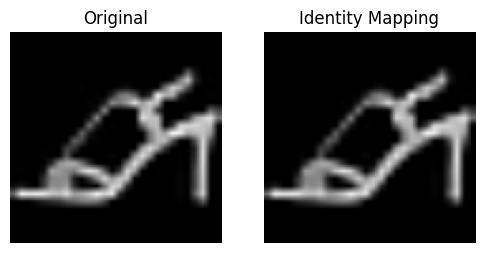

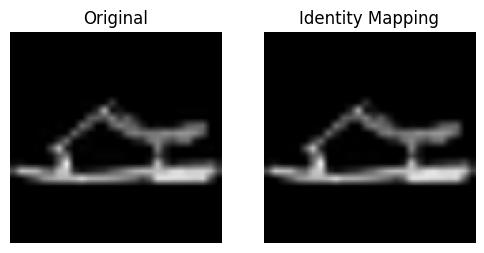

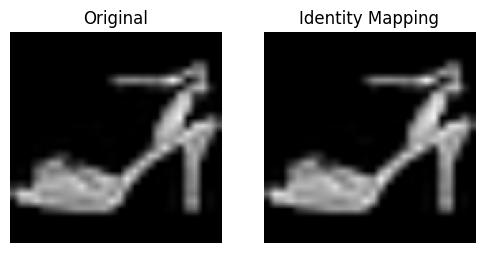

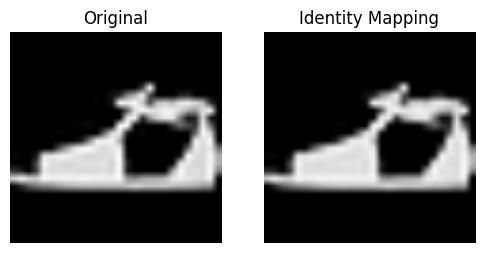

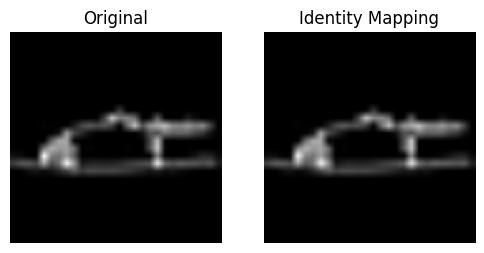

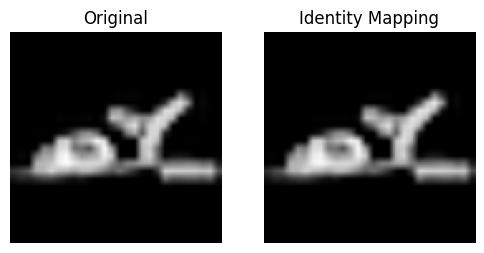

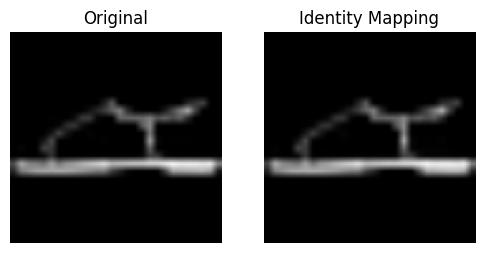

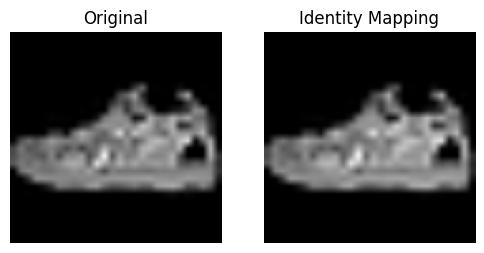

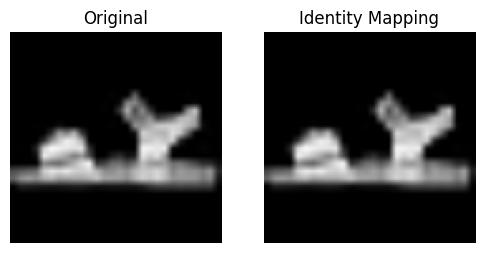

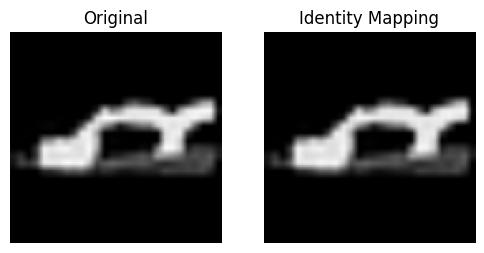

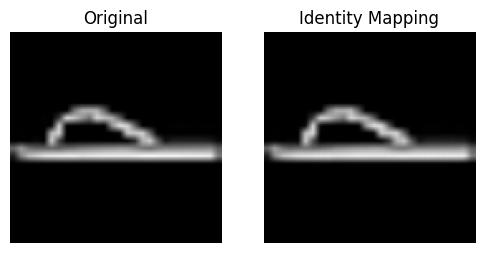

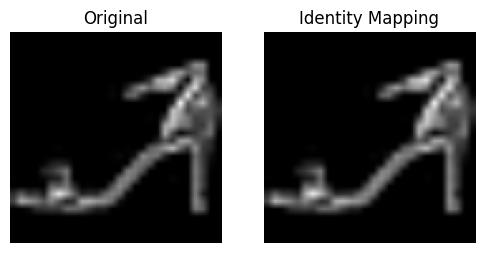

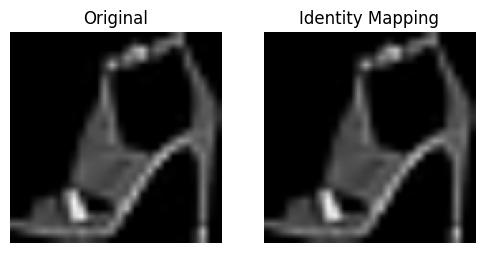

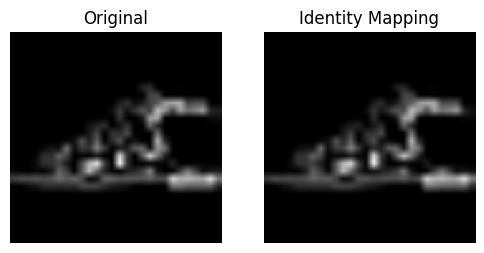

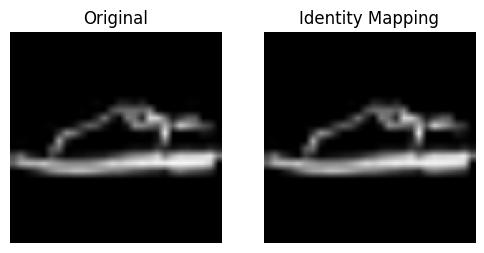

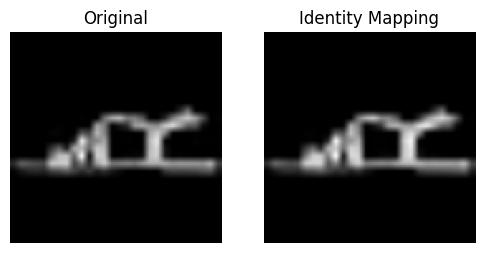

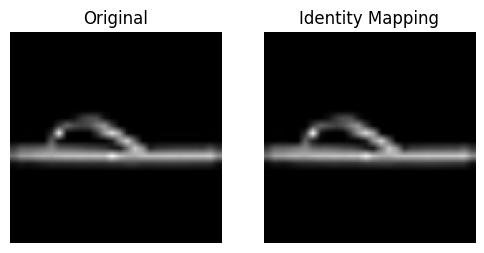

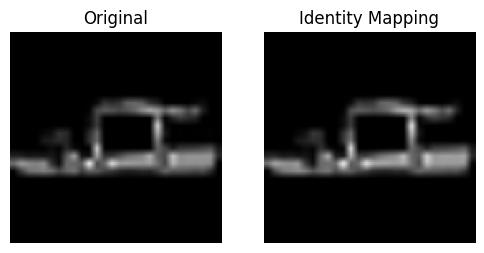

In [ ]:
import os
from random import sample
from PIL import Image
import torch
from torchvision import transforms

# folder with domain B images
trainB_folder = "/workspace/datasets/fashion/trainB"
all_images = os.listdir(trainA_folder)

# randomly pick 30 images
sample_images = sample(all_images, 30)

# helper to load image without resizing/blurring
def load_image(path):
    img = Image.open(path).convert('L')  # keep grayscale
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    img_tensor = (img_tensor - 0.5) / 0.5  # normalize to [-1,1]
    
    # Duplicate channels to 3 to match pretrained generator
    img_tensor = img_tensor.repeat(1, 3, 1, 1)  # shape [1,3,H,W]
    return img_tensor

# loop through and show identity mapping
for img_name in sample_images:
    img_path = os.path.join(trainA_folder, img_name)
    img_tensor = load_image(img_path)
    show_identity(img_tensor, G_A)


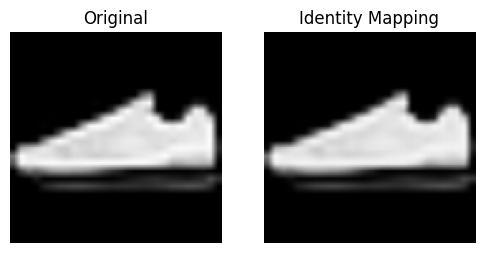

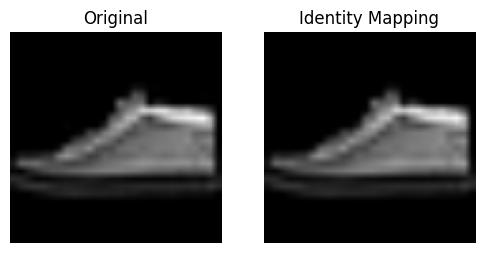

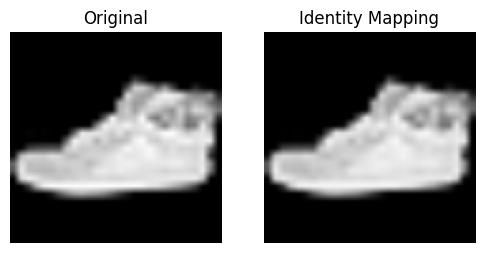

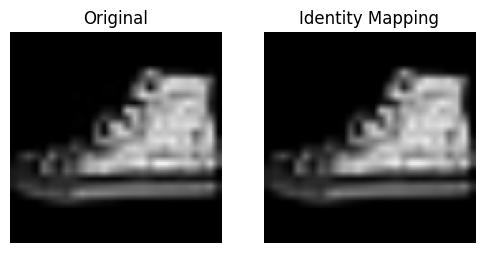

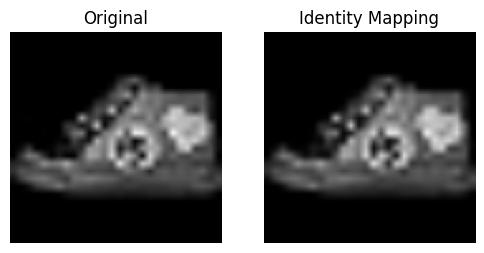

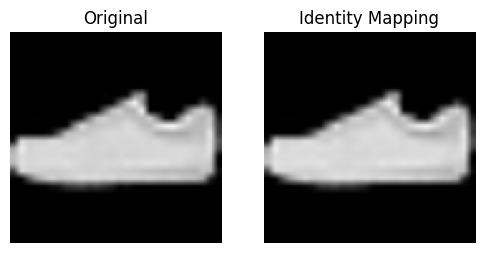

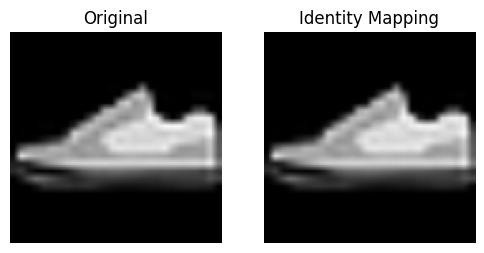

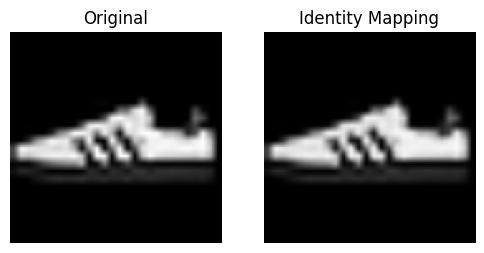

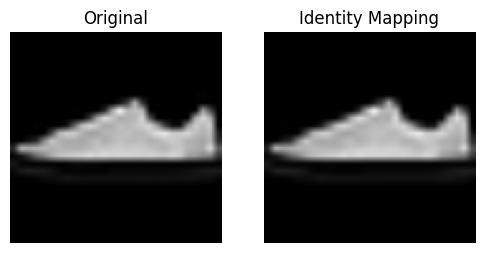

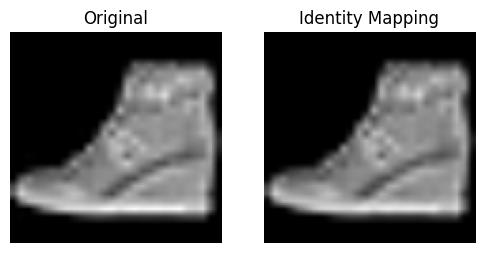

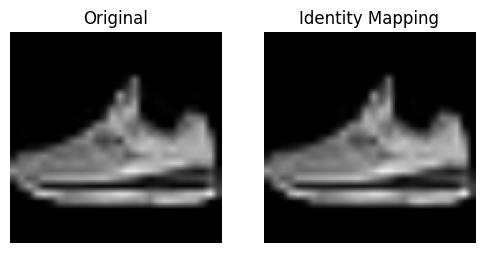

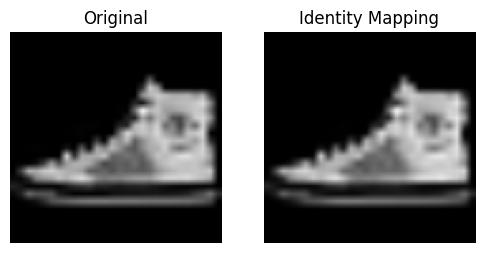

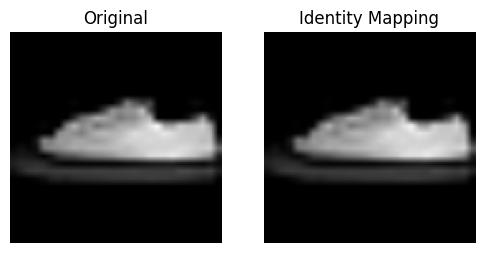

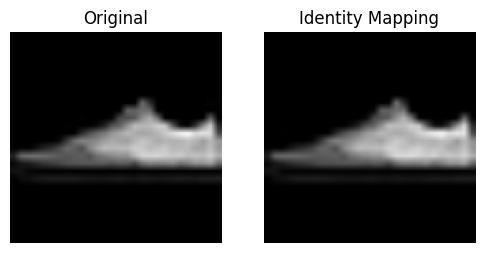

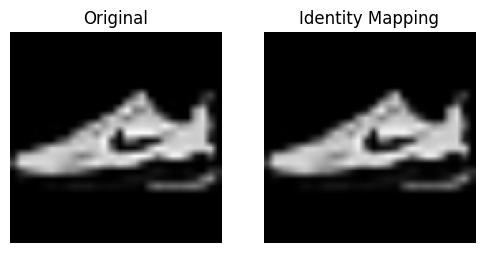

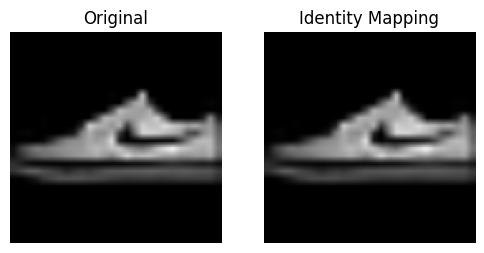

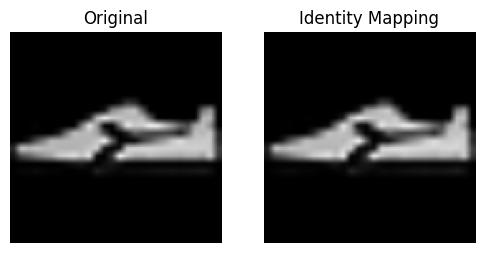

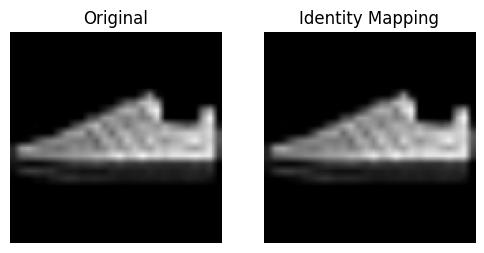

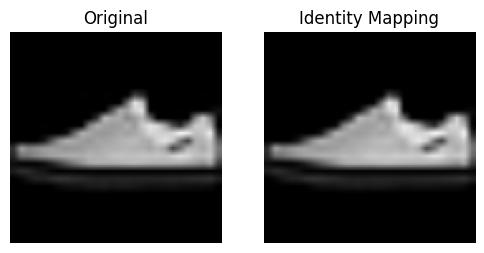

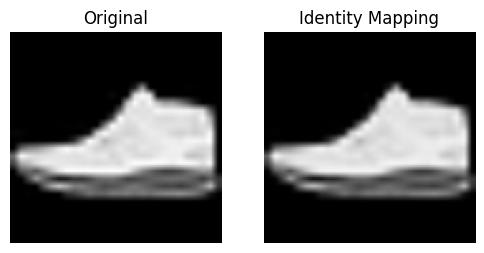

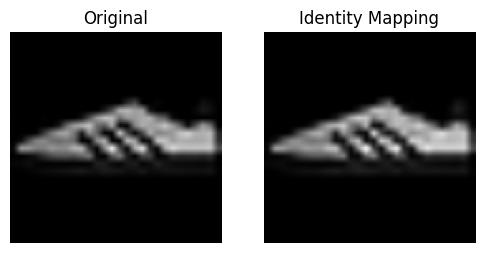

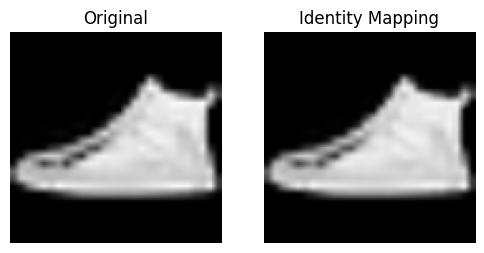

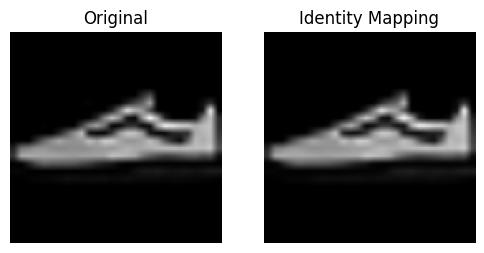

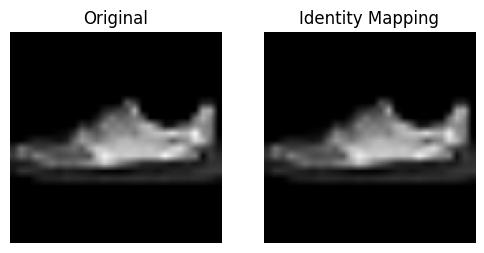

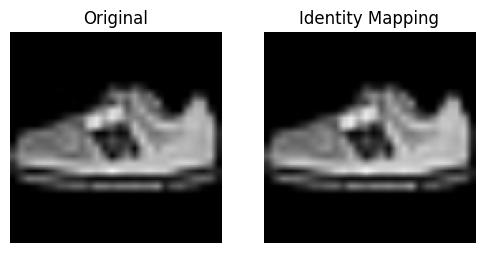

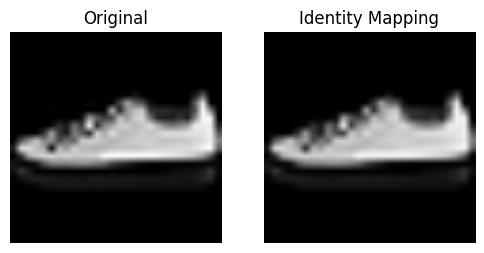

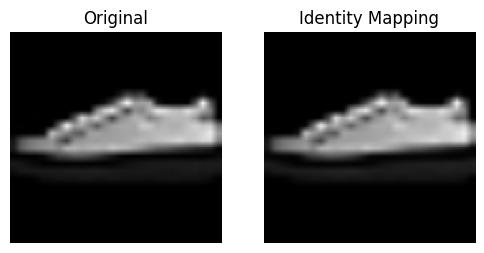

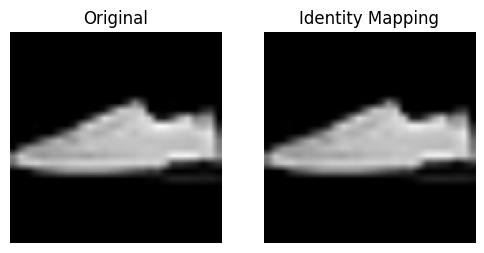

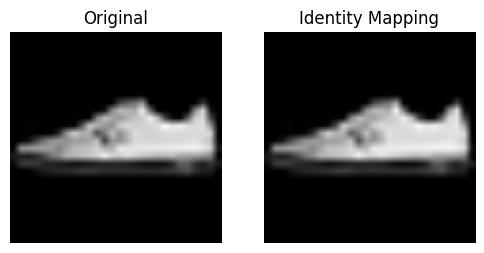

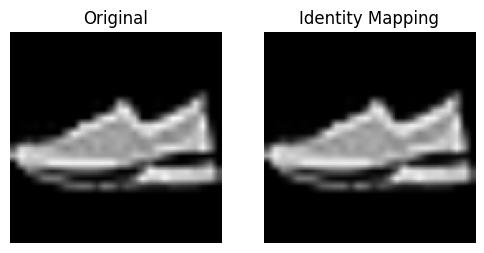

In [133]:
import os
from random import sample
from PIL import Image
import torch
from torchvision import transforms

# folder with domain B images
trainB_folder = "/workspace/datasets/fashion/trainB"
all_images = os.listdir(trainB_folder)

# randomly pick 30 images
sample_images = sample(all_images, 30)

# helper to load image without resizing/blurring
def load_image(path):
    img = Image.open(path).convert('L')  # keep grayscale
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    img_tensor = (img_tensor - 0.5) / 0.5  # normalize to [-1,1]
    
    # Duplicate channels to 3 to match pretrained generator
    img_tensor = img_tensor.repeat(1, 3, 1, 1)  # shape [1,3,H,W]
    return img_tensor

# loop through and show identity mapping
for img_name in sample_images:
    img_path = os.path.join(trainB_folder, img_name)
    img_tensor = load_image(img_path)
    show_identity(img_tensor, G_A)


**Observations:**  

Visually, the **identity-mapped images** for both the domains are highly similar to the original images, indicating that the **identity loss is minimal** and the generator preserves images that are already in the target domain.


## **5. Evaluation Metrics**

To quantitatively evaluate the quality of the generated images, we use the following metrics:

### **1. Mean Squared Error (MSE)**
- It measures the average squared difference between corresponding pixels of the generated and reference images.  
- Lower MSE indicates that the generated image is closer to the reference image.  

### **2. Structural Similarity Index (SSIM)**
- It measures the perceptual similarity between two images, focusing on luminance, contrast, and structure.  
- It ranges from -1 to 1, closer to 1 indicates higher structural similarity.  
- It is more aligned with human perception than MSE.  

### **3. Peak Signal-to-Noise Ratio (PSNR)**
- It measures the ratio between the maximum possible pixel value and the power of the noise (error) in the generated image.  
- A higher PSNR indicates better quality (less error).   

In [110]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from random import sample

def compute_cycle_metrics(dataset, G_forward, G_backward, device, num_images=100):
    num_images = min(num_images, len(dataset))
    indices = sample(range(len(dataset)), num_images)

    mse_list, ssim_list, psnr_list = [], [], []

    for idx in indices:
        img_tensor = dataset[idx][0].unsqueeze(0).to(device)  # 1xCxHxW

        with torch.no_grad():
            fake = G_forward(img_tensor)
            cycle = G_backward(fake)

        # Denormalize [-1,1] -> [0,1]
        orig = (img_tensor[0] * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)
        cyc  = (cycle[0] * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)

        # Compute metrics
        mse_val  = np.mean((orig - cyc)**2)
        ssim_val = ssim(orig, cyc, channel_axis=2, data_range=1.0)
        psnr_val = psnr(orig, cyc, data_range=1.0)

        mse_list.append(mse_val)
        ssim_list.append(ssim_val)
        psnr_list.append(psnr_val)

    return mse_list, ssim_list, psnr_list

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Domain A (A -> B -> A) ----
mse_A, ssim_A, psnr_A = compute_cycle_metrics(
    dataset=datasetA,
    G_forward=model.netG_A,
    G_backward=model.netG_B,
    device=device,
    num_images=100
)

# ---- Domain B (B -> A -> B) ----
mse_B, ssim_B, psnr_B = compute_cycle_metrics(
    dataset=datasetB,
    G_forward=model.netG_B,
    G_backward=model.netG_A,
    device=device,
    num_images=100
)

# Print averages
print("=== Domain A (A->B->A) Average Metrics ===")
print(f"MSE: {np.mean(mse_A):.4f}, SSIM: {np.mean(ssim_A):.4f}, PSNR: {np.mean(psnr_A):.2f}\n")

print("=== Domain B (B->A->B) Average Metrics ===")
print(f"MSE: {np.mean(mse_B):.4f}, SSIM: {np.mean(ssim_B):.4f}, PSNR: {np.mean(psnr_B):.2f}\n")

# Optional: per-image metrics
print("=== Domain A per-image metrics ===")
for i, (m, s, p) in enumerate(zip(mse_A, ssim_A, psnr_A)):
    print(f"Image {i+1:03d}: MSE={m:.4f}, SSIM={s:.4f}, PSNR={p:.2f}")

print("\n=== Domain B per-image metrics ===")
for i, (m, s, p) in enumerate(zip(mse_B, ssim_B, psnr_B)):
    print(f"Image {i+1:03d}: MSE={m:.4f}, SSIM={s:.4f}, PSNR={p:.2f}")


=== Domain A (A->B->A) Average Metrics ===
MSE: 0.0003, SSIM: 0.9537, PSNR: 34.61

=== Domain B (B->A->B) Average Metrics ===
MSE: 0.0005, SSIM: 0.9776, PSNR: 32.77

=== Domain A per-image metrics ===
Image 001: MSE=0.0003, SSIM=0.9537, PSNR=34.61

=== Domain B per-image metrics ===
Image 001: MSE=0.0005, SSIM=0.9776, PSNR=32.77


**Observations:**  
The average **cycle reconstruction metrics** for both domains are very good, with extremely low **MSE**, high **SSIM**, and good **PSNR**. This indicates that the generators **preserve the original structure well** and the images can be **reconstructed accurately** through the cycle-consistency mapping.


In [134]:
import os
from random import sample
from PIL import Image
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from torchvision import transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Helper to load image ----
def load_image(path):
    img = Image.open(path).convert('L')  # keep grayscale
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    img_tensor = (img_tensor - 0.5) / 0.5  # normalize to [-1,1]
    img_tensor = img_tensor.repeat(1,3,1,1)  # duplicate channels to 3
    return img_tensor

# ---- Compute identity metrics for G_A (B -> G_A) ----
def identity_metrics_GA(folder_B, G_A, num_images=100):
    all_images = os.listdir(folder_B)
    sample_images = sample(all_images, min(num_images, len(all_images)))

    G_A.to(device).eval()

    mse_list, ssim_list, psnr_list = [], [], []

    for img_name in sample_images:
        img_tensor = load_image(os.path.join(folder_B, img_name))
        with torch.no_grad():
            identity = G_A(img_tensor)

        # De-normalize
        def denorm(tensor):
            return (tensor * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)

        orig_img = denorm(img_tensor[0])
        idt_img  = denorm(identity[0])

        # Metrics
        mse_list.append(np.mean((orig_img - idt_img)**2))
        ssim_list.append(ssim(orig_img, idt_img, channel_axis=2, data_range=1.0))
        psnr_list.append(psnr(orig_img, idt_img, data_range=1.0))

    # Print averages
    print("=== Identity Metrics for G_A (B -> G_A) ===")
    print(f"MSE  = {np.mean(mse_list):.4f}")
    print(f"SSIM = {np.mean(ssim_list):.3f}")
    print(f"PSNR = {np.mean(psnr_list):.2f}")

# ---- Usage ----
identity_metrics_GA("/workspace/datasets/fashion/trainB", model.netG_A, num_images=100)


=== Identity Metrics for G_A (B -> G_A) ===
MSE  = 0.0001
SSIM = 0.994
PSNR = 41.49


In [135]:
# ---- Compute identity metrics for G_B (A -> G_B) ----
def identity_metrics_GB(folder_A, G_B, num_images=100):
    all_images = os.listdir(folder_A)
    sample_images = sample(all_images, min(num_images, len(all_images)))

    G_B.to(device).eval()

    mse_list, ssim_list, psnr_list = [], [], []

    for img_name in sample_images:
        img_tensor = load_image(os.path.join(folder_A, img_name))
        with torch.no_grad():
            identity = G_B(img_tensor)

        # De-normalize
        def denorm(tensor):
            return (tensor * 0.5 + 0.5).clamp(0,1).cpu().numpy().transpose(1,2,0)

        orig_img = denorm(img_tensor[0])
        idt_img  = denorm(identity[0])

        # Metrics
        mse_list.append(np.mean((orig_img - idt_img)**2))
        ssim_list.append(ssim(orig_img, idt_img, channel_axis=2, data_range=1.0))
        psnr_list.append(psnr(orig_img, idt_img, data_range=1.0))

    # Print averages
    print("=== Identity Metrics for G_B (A -> G_B) ===")
    print(f"MSE  = {np.mean(mse_list):.4f}")
    print(f"SSIM = {np.mean(ssim_list):.3f}")
    print(f"PSNR = {np.mean(psnr_list):.2f}")

# ---- Usage ----
identity_metrics_GB("/workspace/datasets/fashion/trainA", model.netG_B, num_images=100)


=== Identity Metrics for G_B (A -> G_B) ===
MSE  = 0.0001
SSIM = 0.992
PSNR = 39.95


**Observations:**  
The **identity mapping metrics** for both domains are very good, with extremely low **MSE**, high **SSIM**, and high **PSNR**. This indicates that the generators **preserve the structure of the image** when the source and target domain are the same.


In [35]:
import os
import torch
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# Paths
root = "/workspace/datasets/fashion"
real_A = os.path.join(root, "trainA")
real_B = os.path.join(root, "trainB")
fake_A = os.path.join(root, "fakeA")
fake_B = os.path.join(root, "fakeB")

os.makedirs(fake_A, exist_ok=True)
os.makedirs(fake_B, exist_ok=True)

# Device + model eval mode
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.netG_A.to(device).eval()
model.netG_B.to(device).eval()

# Transform (same normalization as training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Reverse normalization for saving
def denorm(tensor):
    img = (tensor * 0.5 + 0.5).clamp(0, 1)
    img = (img * 255).permute(1, 2, 0).cpu().numpy().astype('uint8')
    return Image.fromarray(img)


In [ ]:
! /venv/main/bin/python -m pip install torchmetrics
! /venv/main/bin/python -m pip install torch-fidelity


## **7. Evaluation using FID and IS**

To further evaluate the quality of the generated images, we use two widely-adopted **GAN evaluation metrics**:  

### **1. Fréchet Inception Distance (FID)**
- Measures the distance between the **feature distributions** of real and generated images in a pre-trained Inception network.  
- **Lower FID** indicates that the generated images are **closer in distribution to real images** in the feature space, i.e., higher visual realism.  

### **2. Inception Score (IS)**
- Measures both the **quality** and **diversity** of generated images based on a pre-trained classifier (Inception network).  
- **Higher IS** indicates that images are **realistic, diverse**, and can be confidently classified into distinct categories.


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

fid = FrechetInceptionDistance(feature=2048).to(device)
is_metric = InceptionScore().to(device)


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:08<00:00, 11.7MB/s]
/venv/main/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


In [29]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import os

# -------------------------
# Dataset for single-folder images
# -------------------------
class SingleFolderDataset(torch.utils.data.Dataset):
    def __init__(self, folder_path, transform=None):
        self.images = [os.path.join(folder_path, f)
                       for f in os.listdir(folder_path)
                       if f.lower().endswith(".png")]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# -------------------------
# Transform
# -------------------------
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# -------------------------
# Load datasets
# -------------------------
realA_dataset = SingleFolderDataset("/workspace/datasets/fashion/trainA", transform)
fakeA_dataset = SingleFolderDataset("/workspace/datasets/fashion/trainB", transform)
realB_dataset = SingleFolderDataset("/workspace/datasets/fashion/trainB", transform)
fakeB_dataset = SingleFolderDataset("/workspace/datasets/fashion/trainA", transform)

# DataLoaders
batch_size = 16
realA_loader = DataLoader(realA_dataset, batch_size=batch_size, shuffle=False)
fakeA_loader = DataLoader(fakeA_dataset, batch_size=batch_size, shuffle=False)
realB_loader = DataLoader(realB_dataset, batch_size=batch_size, shuffle=False)
fakeB_loader = DataLoader(fakeB_dataset, batch_size=batch_size, shuffle=False)

# -------------------------
# Initialize metrics
# -------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
fid_metric = FrechetInceptionDistance(feature=2048).to(device)
is_metric = InceptionScore().to(device)

# -------------------------
# Helpers
# -------------------------
def to_uint8(batch):
    return (batch.clamp(0,1) * 255).to(torch.uint8)

# -------------------------
# Compute FID safely
# -------------------------
def compute_fid(real_loader, fake_loader):
    real_count, fake_count = 0, 0

    for batch, _ in real_loader:
        if batch.size(0) <= 1:
            continue
        batch = to_uint8(batch).to(device)
        fid_metric.update(batch, real=True)
        real_count += batch.size(0)

    for batch, _ in fake_loader:
        if batch.size(0) <= 1:
            continue
        batch = to_uint8(batch).to(device)
        fid_metric.update(batch, real=False)
        fake_count += batch.size(0)

    if real_count < 2 or fake_count < 2:
        raise RuntimeError("Need at least 2 samples per distribution to compute FID")

    fid_val = fid_metric.compute()
    fid_metric.reset()
    return fid_val

# -------------------------
# Compute Inception Score safely
# -------------------------
def compute_is(fake_loader):
    total_samples = 0
    for batch, _ in fake_loader:
        if batch.size(0) <= 1:
            continue
        batch = (batch.clamp(0,1) * 255).to(torch.uint8).to(device)
        is_metric.update(batch)
        total_samples += batch.size(0)

    if total_samples < 2:
        raise RuntimeError("Need at least 2 samples to compute Inception Score")

    return is_metric.compute()  # returns (mean, std)

# -------------------------
# Run metrics
# -------------------------
# A → B
fid_A = compute_fid(realA_loader, fakeA_loader)
print(f"FID for A → B: {fid_A.item():.4f}")
IS_A_mean, IS_A_std = compute_is(fakeA_loader)
print(f"Inception Score for fakeA: {IS_A_mean.item():.4f} ± {IS_A_std.item():.4f}")

# B → A
fid_B = compute_fid(realB_loader, fakeB_loader)
print(f"FID for B → A: {fid_B.item():.4f}")
IS_B_mean, IS_B_std = compute_is(fakeB_loader)
print(f"Inception Score for fakeB: {IS_B_mean.item():.4f} ± {IS_B_std.item():.4f}")


FID for A → B: 108.2885
Inception Score for fakeA: 2.7953 ± 0.0842
FID for B → A: 108.2885
Inception Score for fakeB: 3.4212 ± 0.0686


**Observations**

- The **FID scores** for both directions are relatively high (~108), this is because **pre-trained Inception Network** used in FID is trained on **high-resolution images**, whereas our dataset images are **low-resolution (32×32)**.  
- As a result, the feature space does not perfectly align, which artificially increases the FID.  

- The **Inception Scores (IS)** show that the `fakeB` (B → A) images have a higher score (~3.42) than `fakeA` (A → B) (~2.79) images. This indicates that the generator mapping to **domain B** produces images that are **more diverse** and **more confidently classified** by the Inception network.
  
